# 3.6: Model performance comparison
This notebook will assess the performance of the models generated in step 3.3, 3.4 and 3.5. 

## 3.6.1 system setup

In [1]:
%load_ext autoreload
%autoreload 2

In [44]:
import pandas as pd
import os
import sys
import numpy as np
import json
from plotly.subplots import make_subplots

import plotly.graph_objects as go


sys.path.append('../../utils')
from  configloader import Configloader
import cnn_helpers
import implot
import file_io
import style

#from sklearn.preprocessing import LabelEncoder
#import tensorflow as tf

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-05-01 17:26:12.666003: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-01 17:26:15.008361: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-01 17:26:15.008445: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [4]:
config = Configloader()

basedir = config.get('settings', 'image_directory')
csv_data_dir = config.get('dir_augmentations', 'csv_dir')

#augment_base = os.path.join(basedir, 'augmentated data', 'brand phase')


In [5]:
CNN_SHAPE = 224

PHASE = 'brand phase'

MODELDIR = os.path.join(
    config.get('directories', 'root_dir'), 
    config.get('directories', 'final_models_dirname'), 
    config.get('directories', 'brandphase'),
    )

CROP = True  #crop on bbox

In [6]:
csv_dir = os.path.join(basedir, csv_data_dir, PHASE)  #where the train/test/valid split in step 3.1 was done.

## 3.6.2 Data loading
This notebook will use NON-augemented data from the validation set! 

In [7]:
validation_df_path = os.path.join(csv_dir, config.get('csv_names', 'brand_validation'))
validation_df = pd.read_csv(validation_df_path)

In [8]:
validation_df = cnn_helpers.shuffle_df(validation_df)
validation_df

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path
0,12526365,frontleft,1.000000,91,93,552,400,12526365,0.988619,0.997926,0.698918,0.088903,volkswagen,/home/frederic/Documents/automotive_image_data...
1,8206802,front,1.000000,108,114,645,513,8206802,0.998616,0.999997,0.994471,0.997850,land-rover,/home/frederic/Documents/automotive_image_data...
2,8044735,frontright,0.999875,11,52,422,491,8044735,0.015148,0.926809,0.558228,0.919790,mini,/home/frederic/Documents/automotive_image_data...
3,10335146,rearright,1.000000,-1,-1,-1,-1,10335146,0.999966,1.000000,0.999050,0.999765,land-rover,/home/frederic/Documents/automotive_image_data...
4,9607947,right,0.995833,18,162,677,408,9607947,0.984825,0.999624,0.982360,0.990144,porsche,/home/frederic/Documents/automotive_image_data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399056,8589466,rear,1.000000,137,85,623,492,8589466,0.996965,0.999986,0.991954,0.721839,suzuki,/home/frederic/Documents/automotive_image_data...
399057,3464407,right,1.000000,21,163,727,458,3464407,0.998561,0.999635,0.942808,0.999864,audi,/home/frederic/Documents/automotive_image_data...
399058,7409536,left,1.000000,15,196,745,488,7409536,0.977144,0.993057,0.488512,0.558256,opel,/home/frederic/Documents/automotive_image_data...
399059,5388527,right,0.999996,28,107,741,442,5388527,0.979066,0.999950,0.980637,0.989020,mercedes-benz,/home/frederic/Documents/automotive_image_data...


In [9]:
#RUN SMALL TEST #TODO remove this
# validation_df = validation_df.sample(20000)

In [10]:
g = implot.quickplot(validation_df, 'model_label')
g.update_layout(
    title='Distribution of angles in validation set', 
    width=1000, 
    height=600
    )

In [11]:
g = implot.quickplot(validation_df, 'brand')
g.update_layout(
    title='Distribution of brands in validation set', 
    width=1600, 
    height=900
    )

this is good - we still remember the graphs made in EDA phases and post-applier notebooks that showed similar distributions. Now assess the models. 

## 3.6.3 please note: 
Note that we already have the model tag stored in the CSV generated by the notebook `/notebooks/model appliers/2 - apply_angletag.ipynb`. We'll aplly all models to all images and compare what works best: use the angle-specific model or use the highest performing output. 


In [12]:
# decode_labels = {}

## 3.6.4 Performance assessment of angle based brand models (signle infer)
The highly specialized models that are trained on specific angles are probably very good at inferring the brand from an image if the angle is correclty inferred in phase 2. However, this is not always the case (that model did not perform at an F1 of 100%). In subsection `3.6.3` we will only infer on the angle model that the angle-tagger expects. 

In [13]:
results = {}
test_profile = 'CNN_based_models'
if test_profile not in results:
    results[test_profile] = {}
known_angles = validation_df.model_label.unique()
for subdir in os.listdir(os.path.join(MODELDIR, test_profile)):
    trained_model_dir = os.path.join(MODELDIR, test_profile, subdir)
    # print(subdir)
    #models trained on FULL should be able to process the entire validationdf. 
    if subdir.startswith('full'): 
        df = validation_df
    #Models trained on a specific angle, should only be validated against this angel:
    else:
        if '_' in subdir: 
            angle = subdir.split('_')[0]
        else:
            angle = subdir
        df = validation_df.query('model_label==@angle')
    p,a,decode = cnn_helpers.infer_cnn(trained_model_dir, df, CROP, CNN_SHAPE)
    if subdir not in results[test_profile]:
        results[test_profile][subdir] = {
            'predicts_raw':p,
            'predicts': np.argmax(p, axis=1),
            'actuals':a,
            'decoder': decode
            }

    

2025-05-01 17:26:16.490910: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-01 17:26:16.491059: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-01 17:26:16.491113: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-01 17:26:16.491211: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-01 17:26:16.491265: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

In [ ]:
test_profile = 'ViT_models'
if test_profile not in results:
    results[test_profile] = {}
known_angles = validation_df.model_label.unique()
for subdir in os.listdir(os.path.join(MODELDIR, test_profile)):
    trained_model_dir = os.path.join(MODELDIR, test_profile, subdir)
    #ViT was only trained on a single angle; never on the full dataset. 
    angle = subdir
    df = validation_df.query('model_label==@angle')


In [14]:
def decode_labels(decoder, encoded_labels): 
    return [decoder[i] for i in encoded_labels]


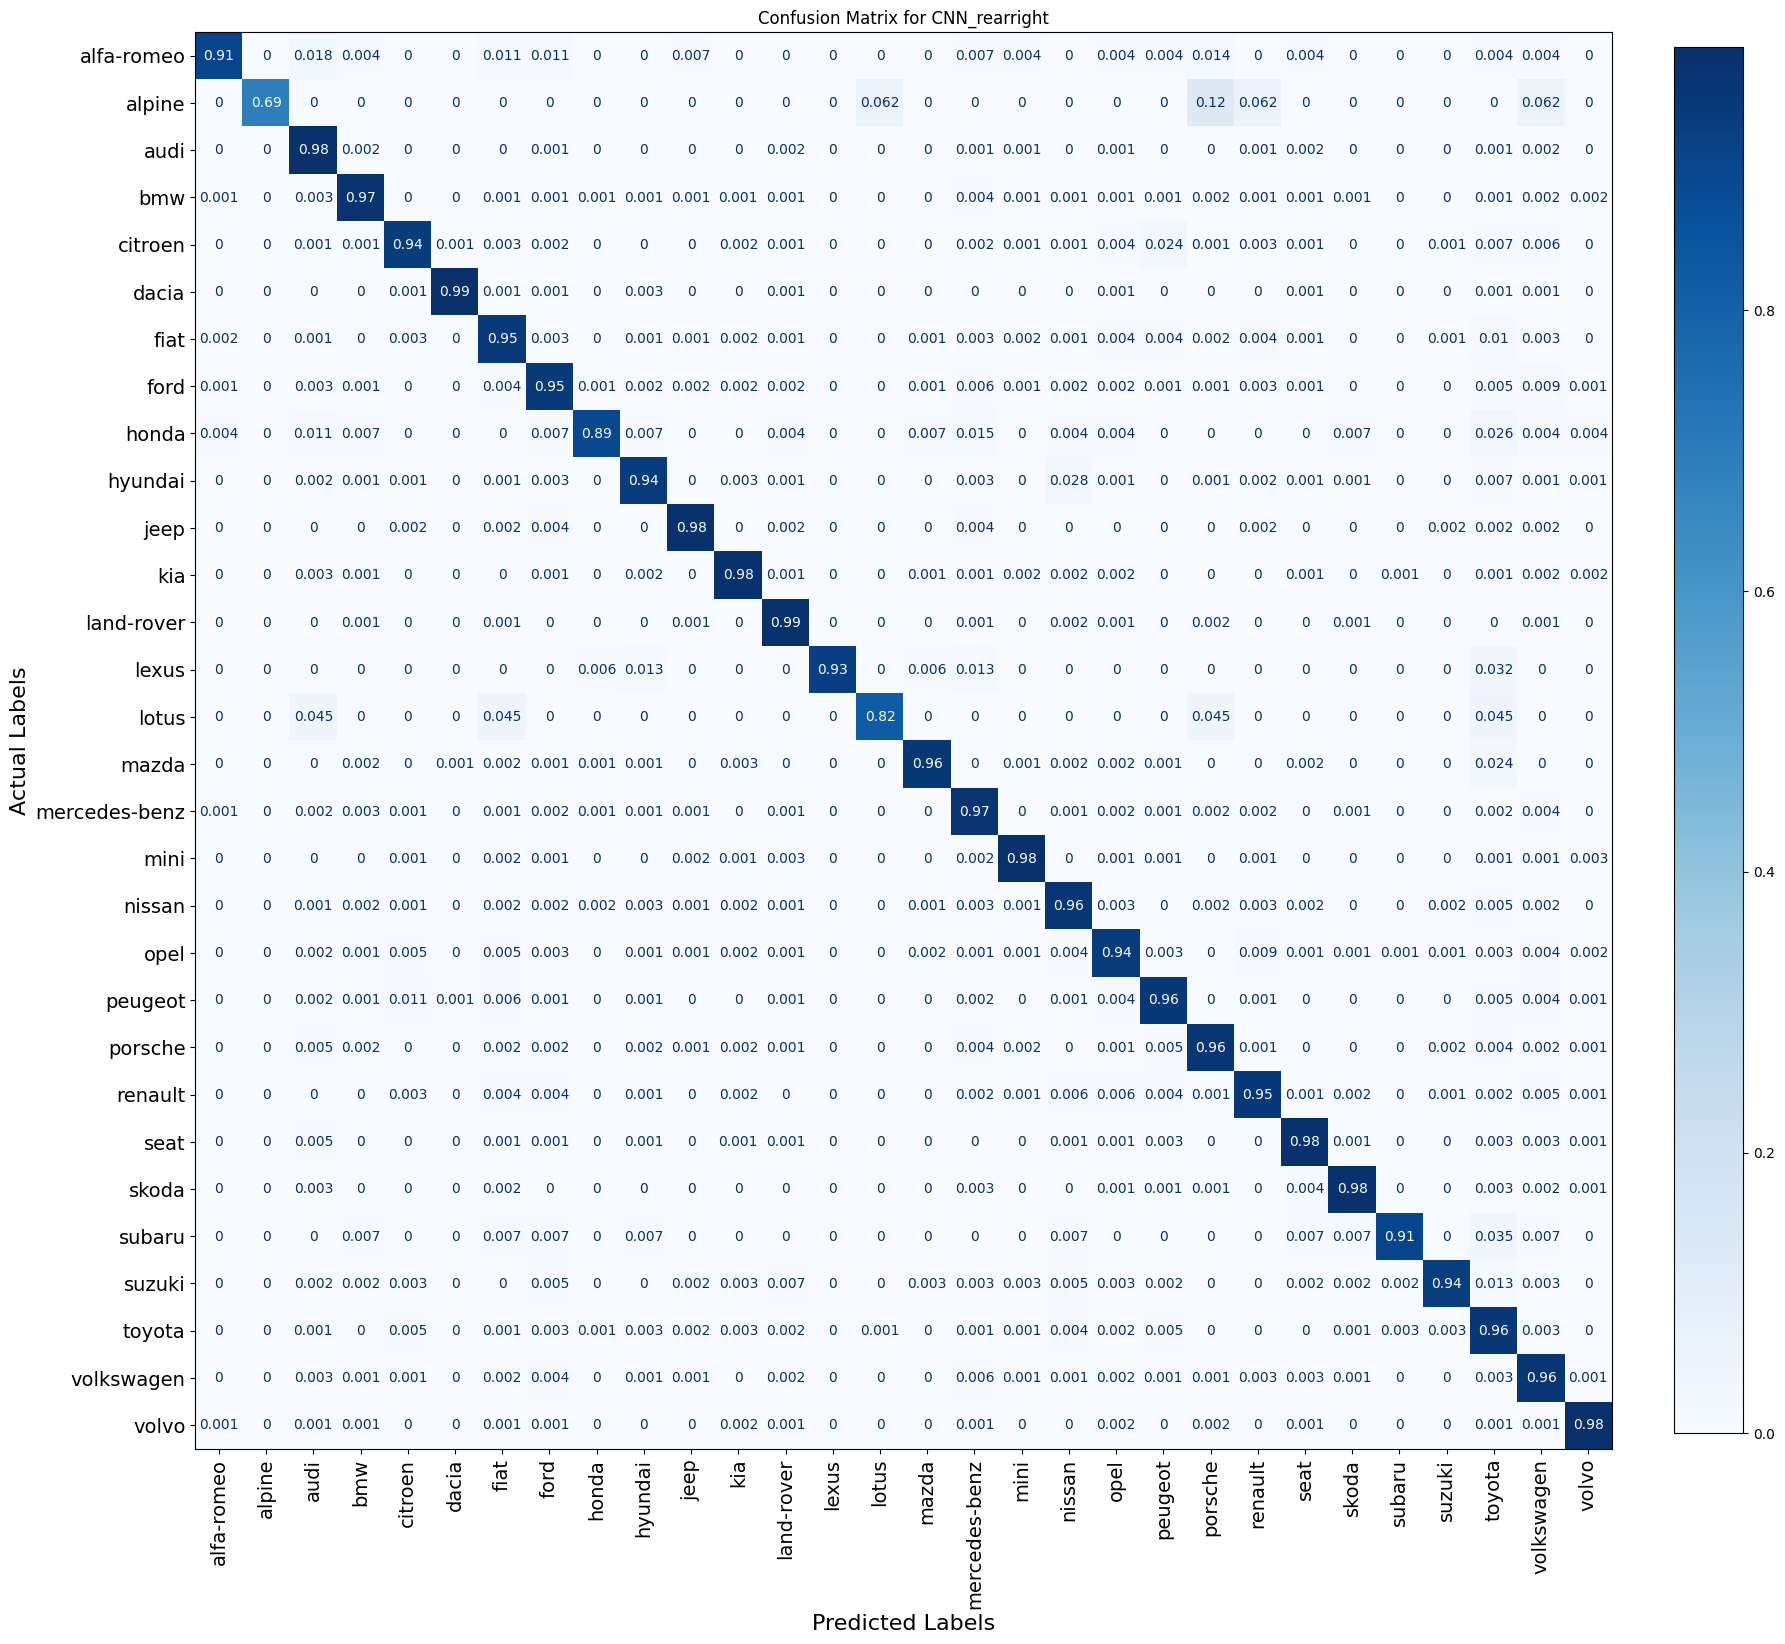

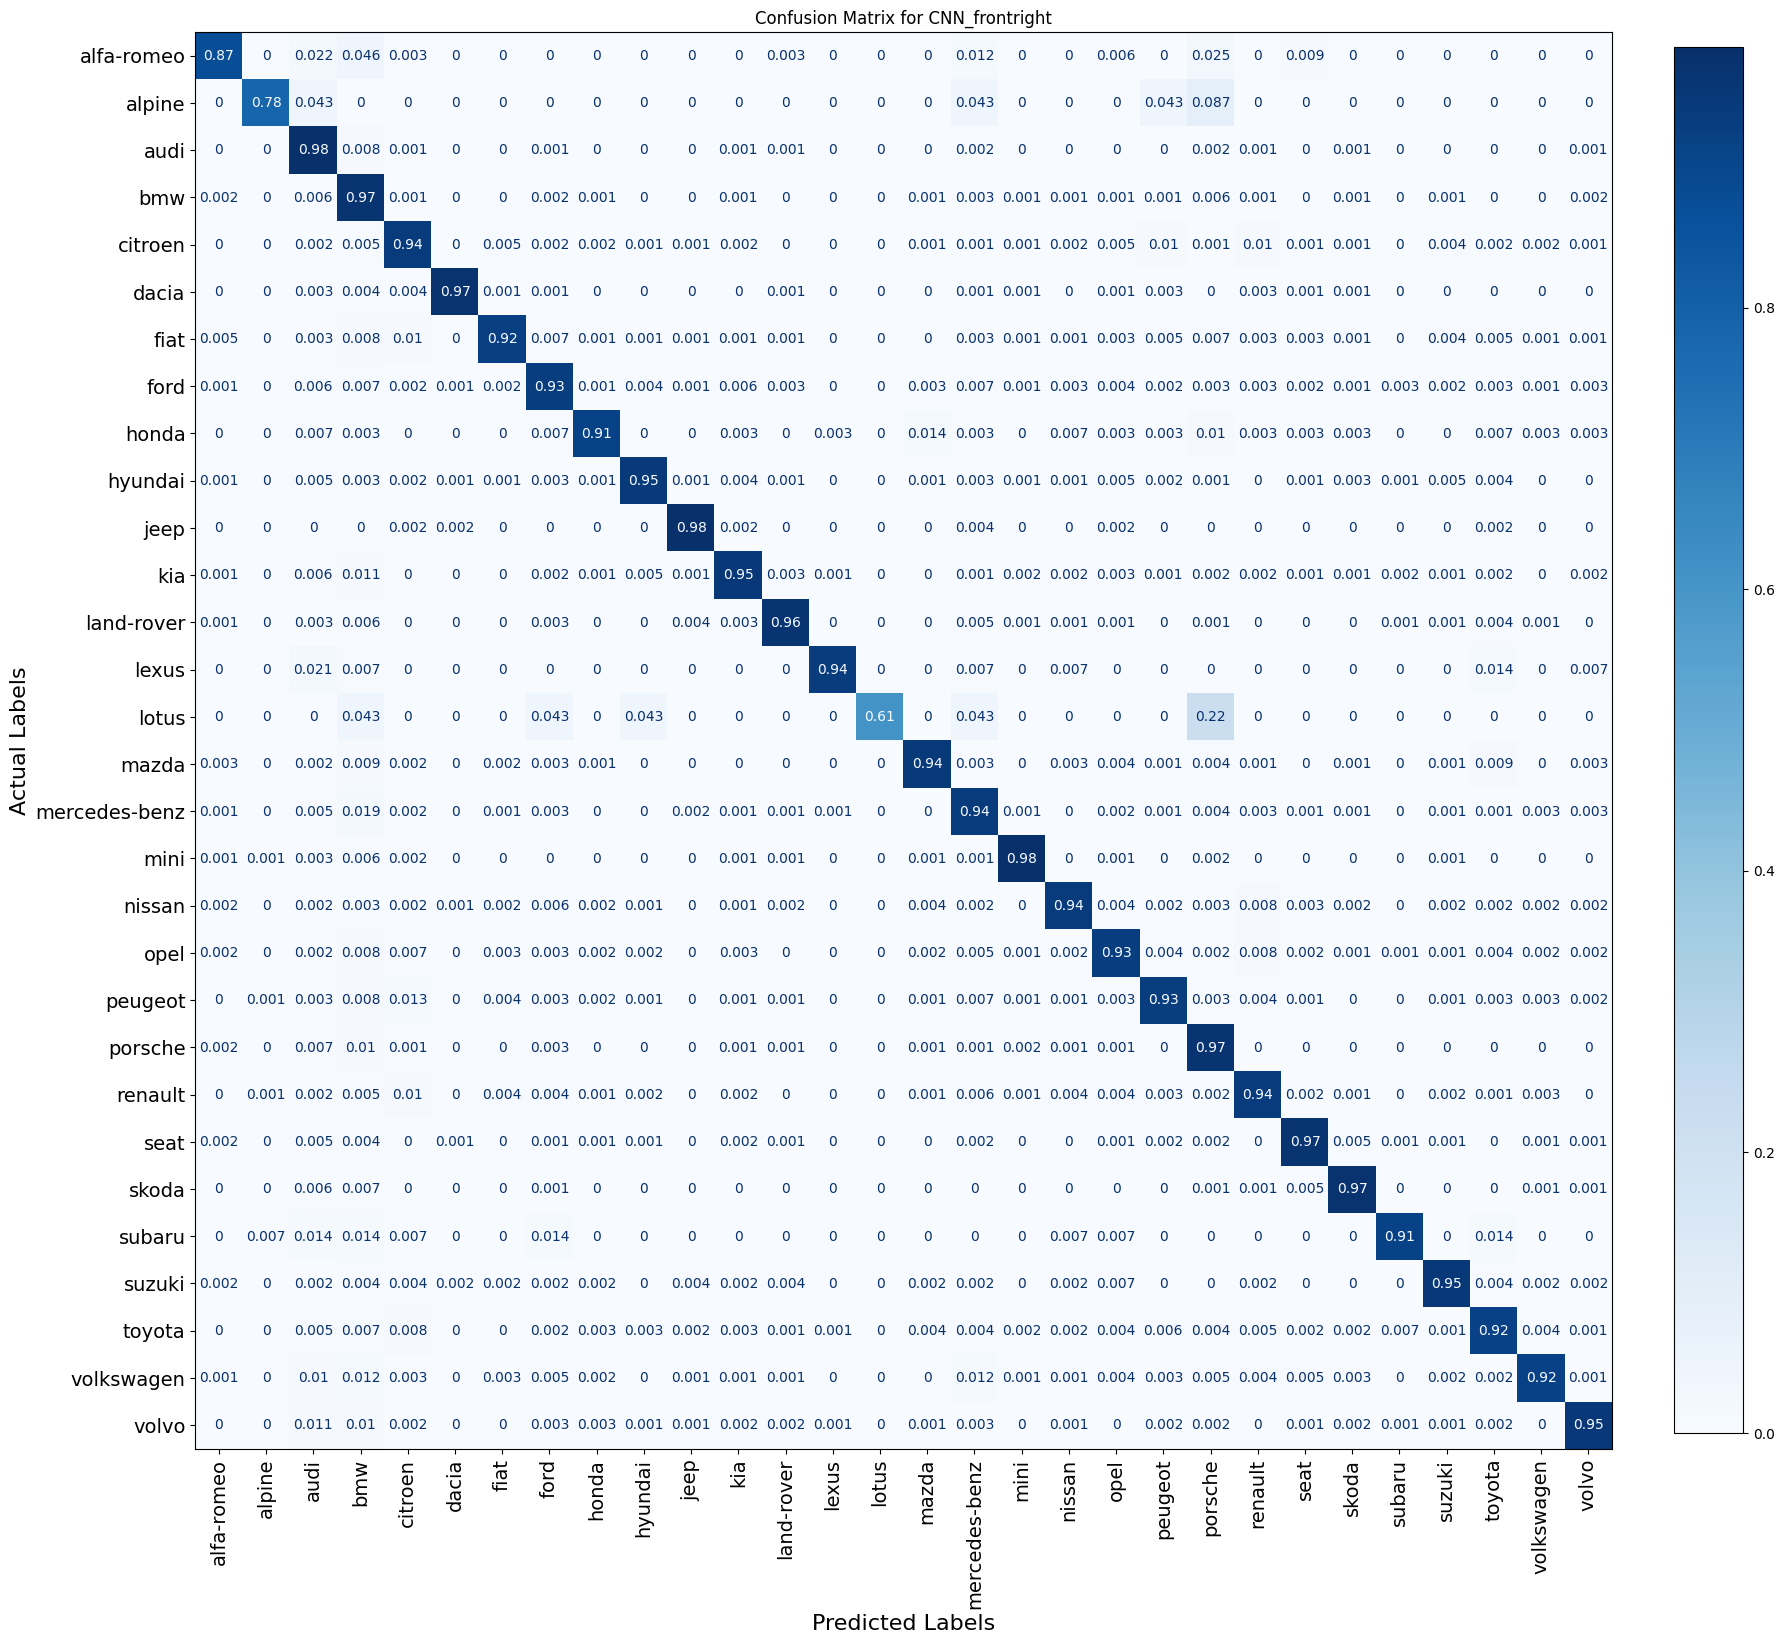

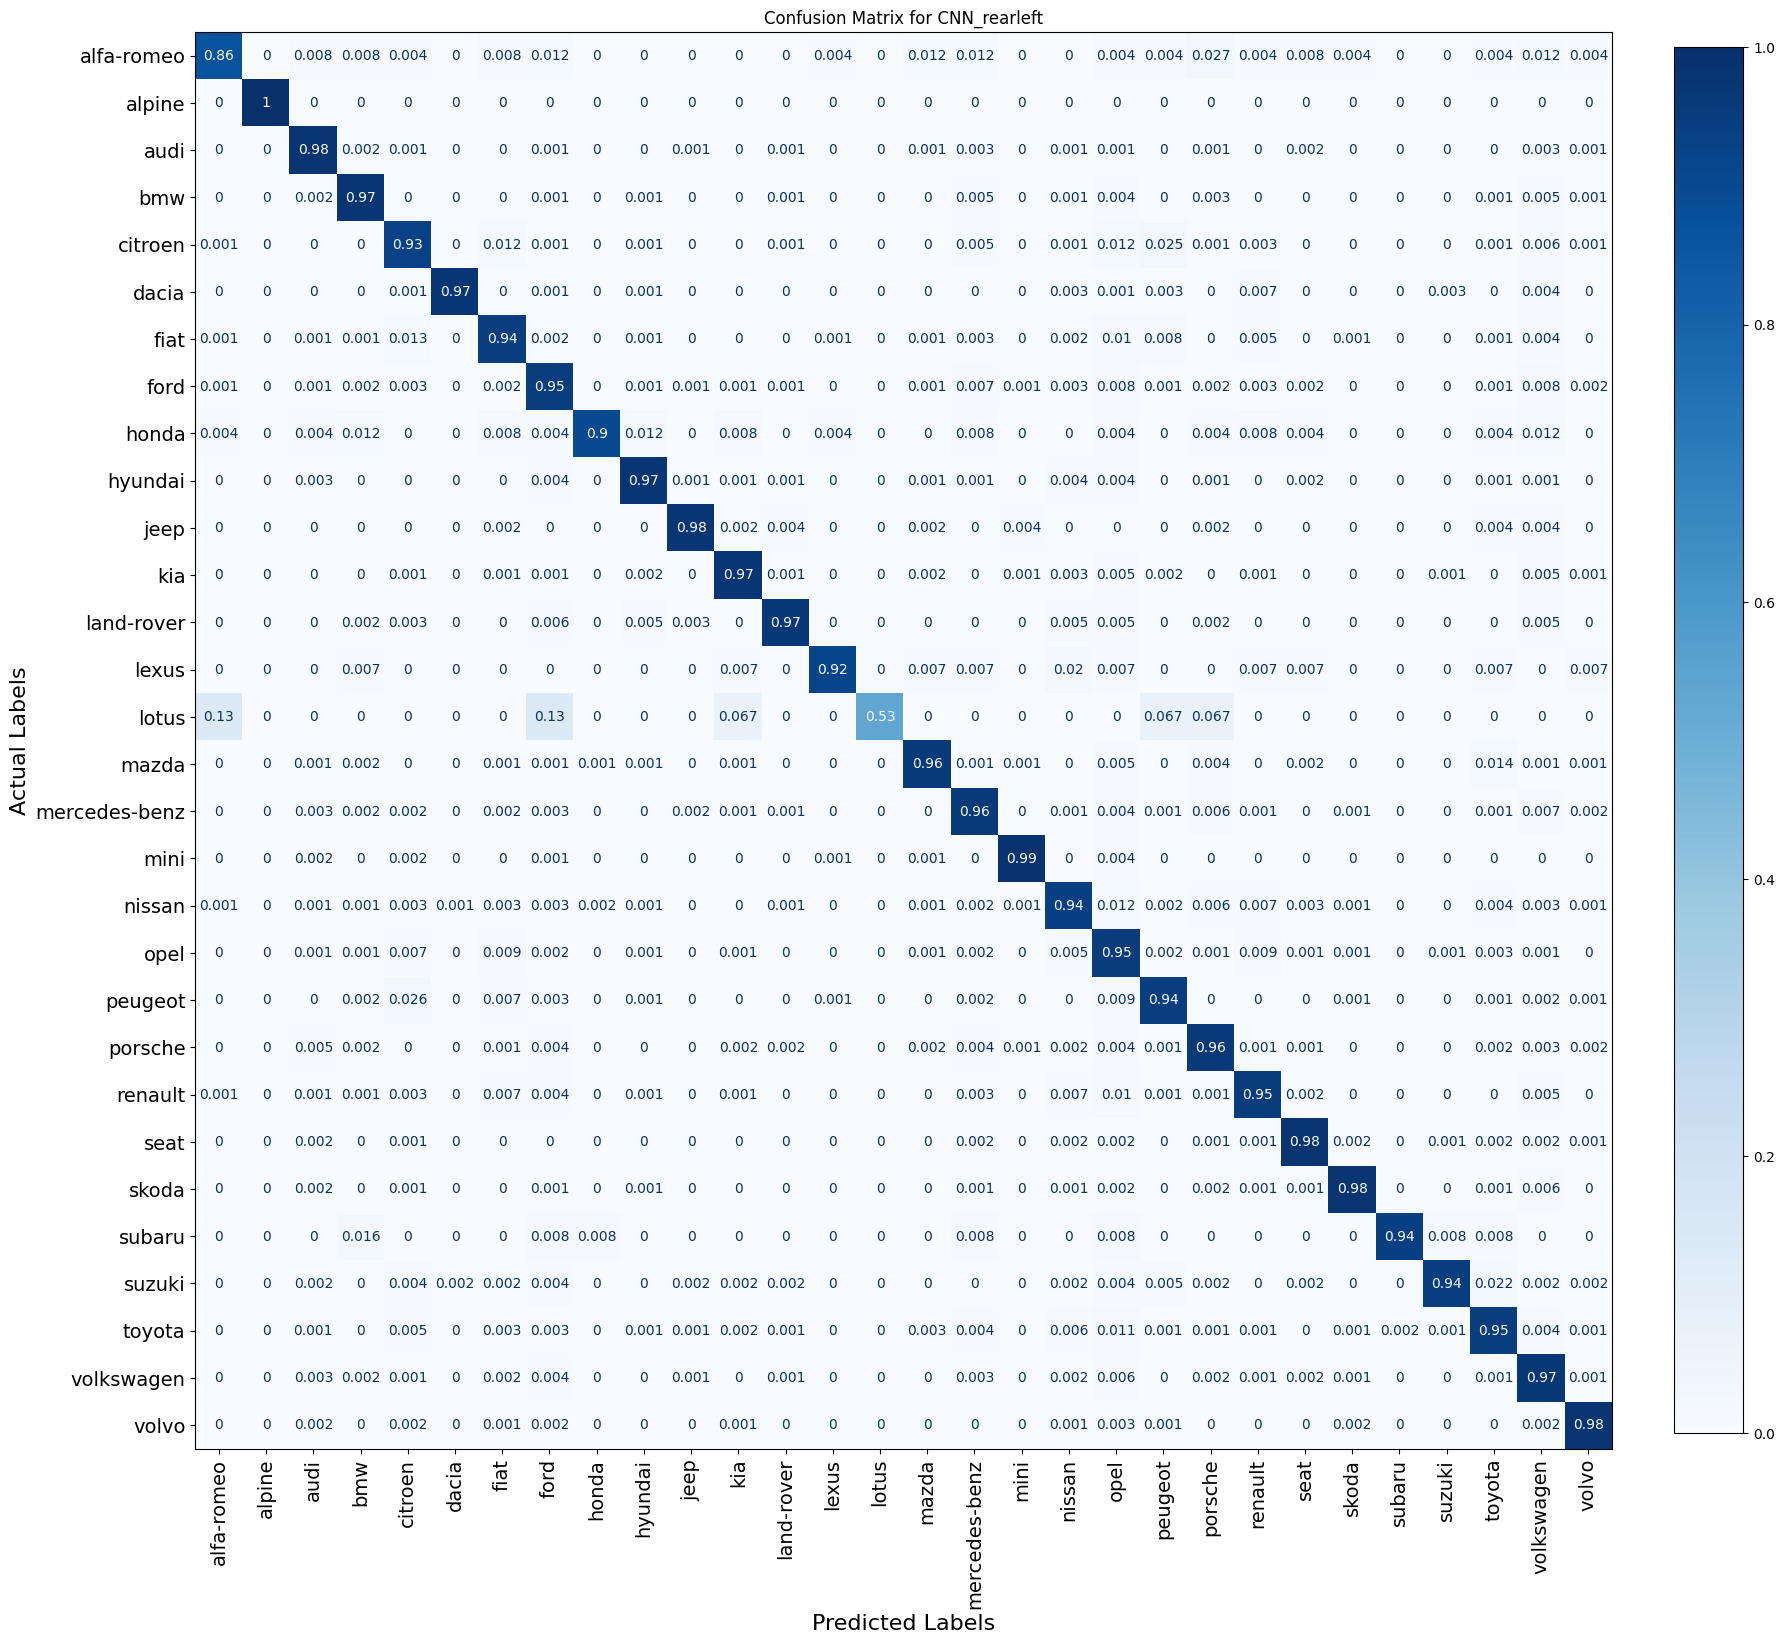

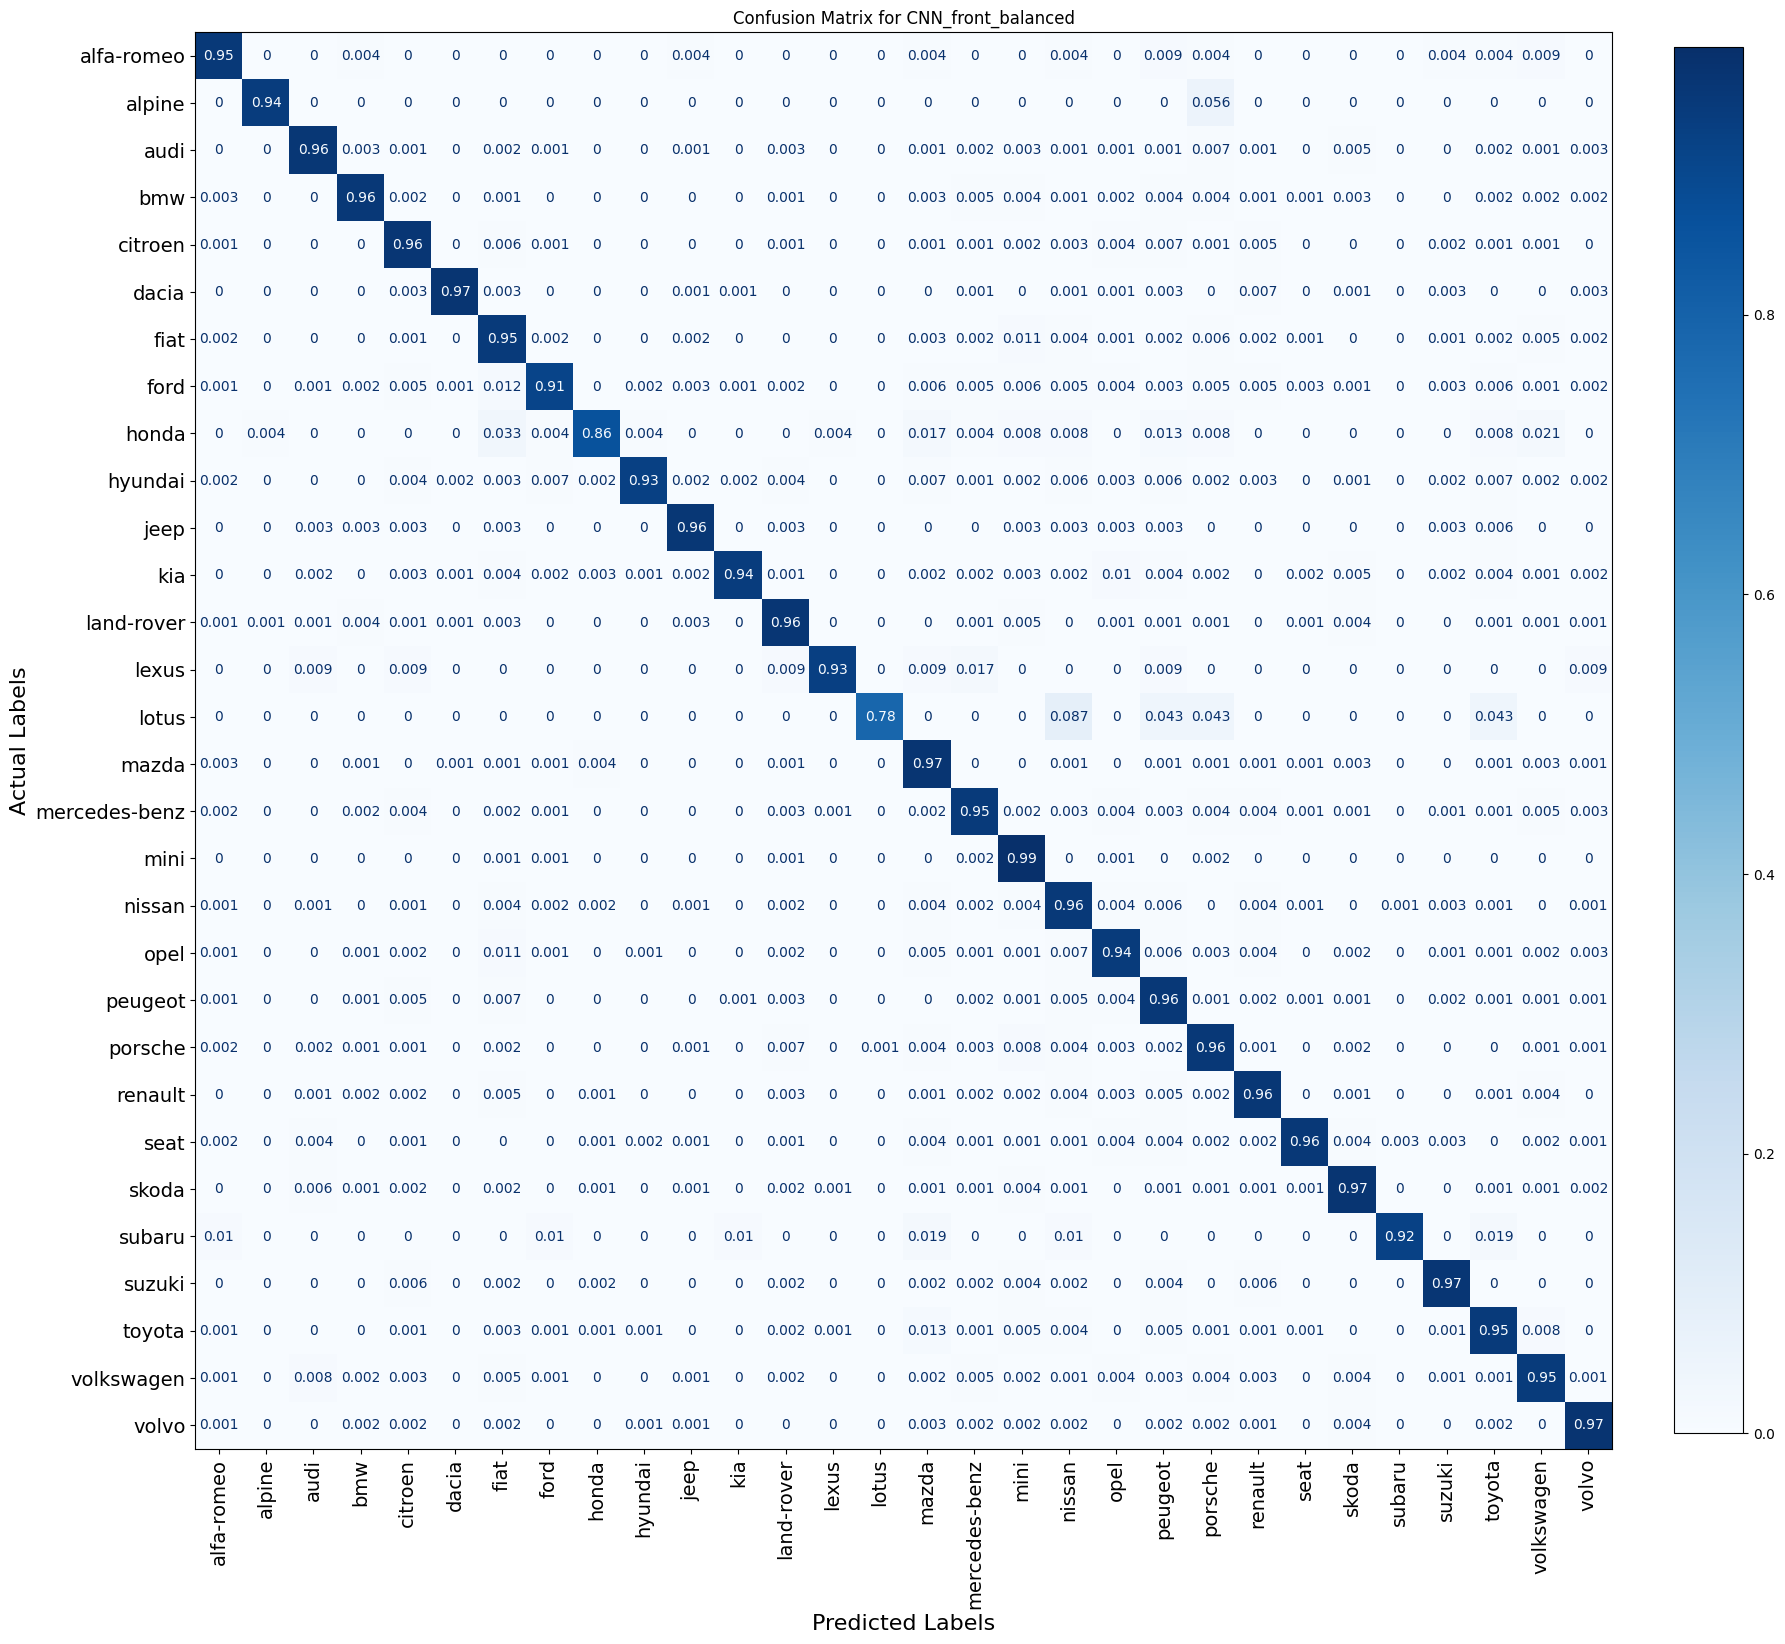

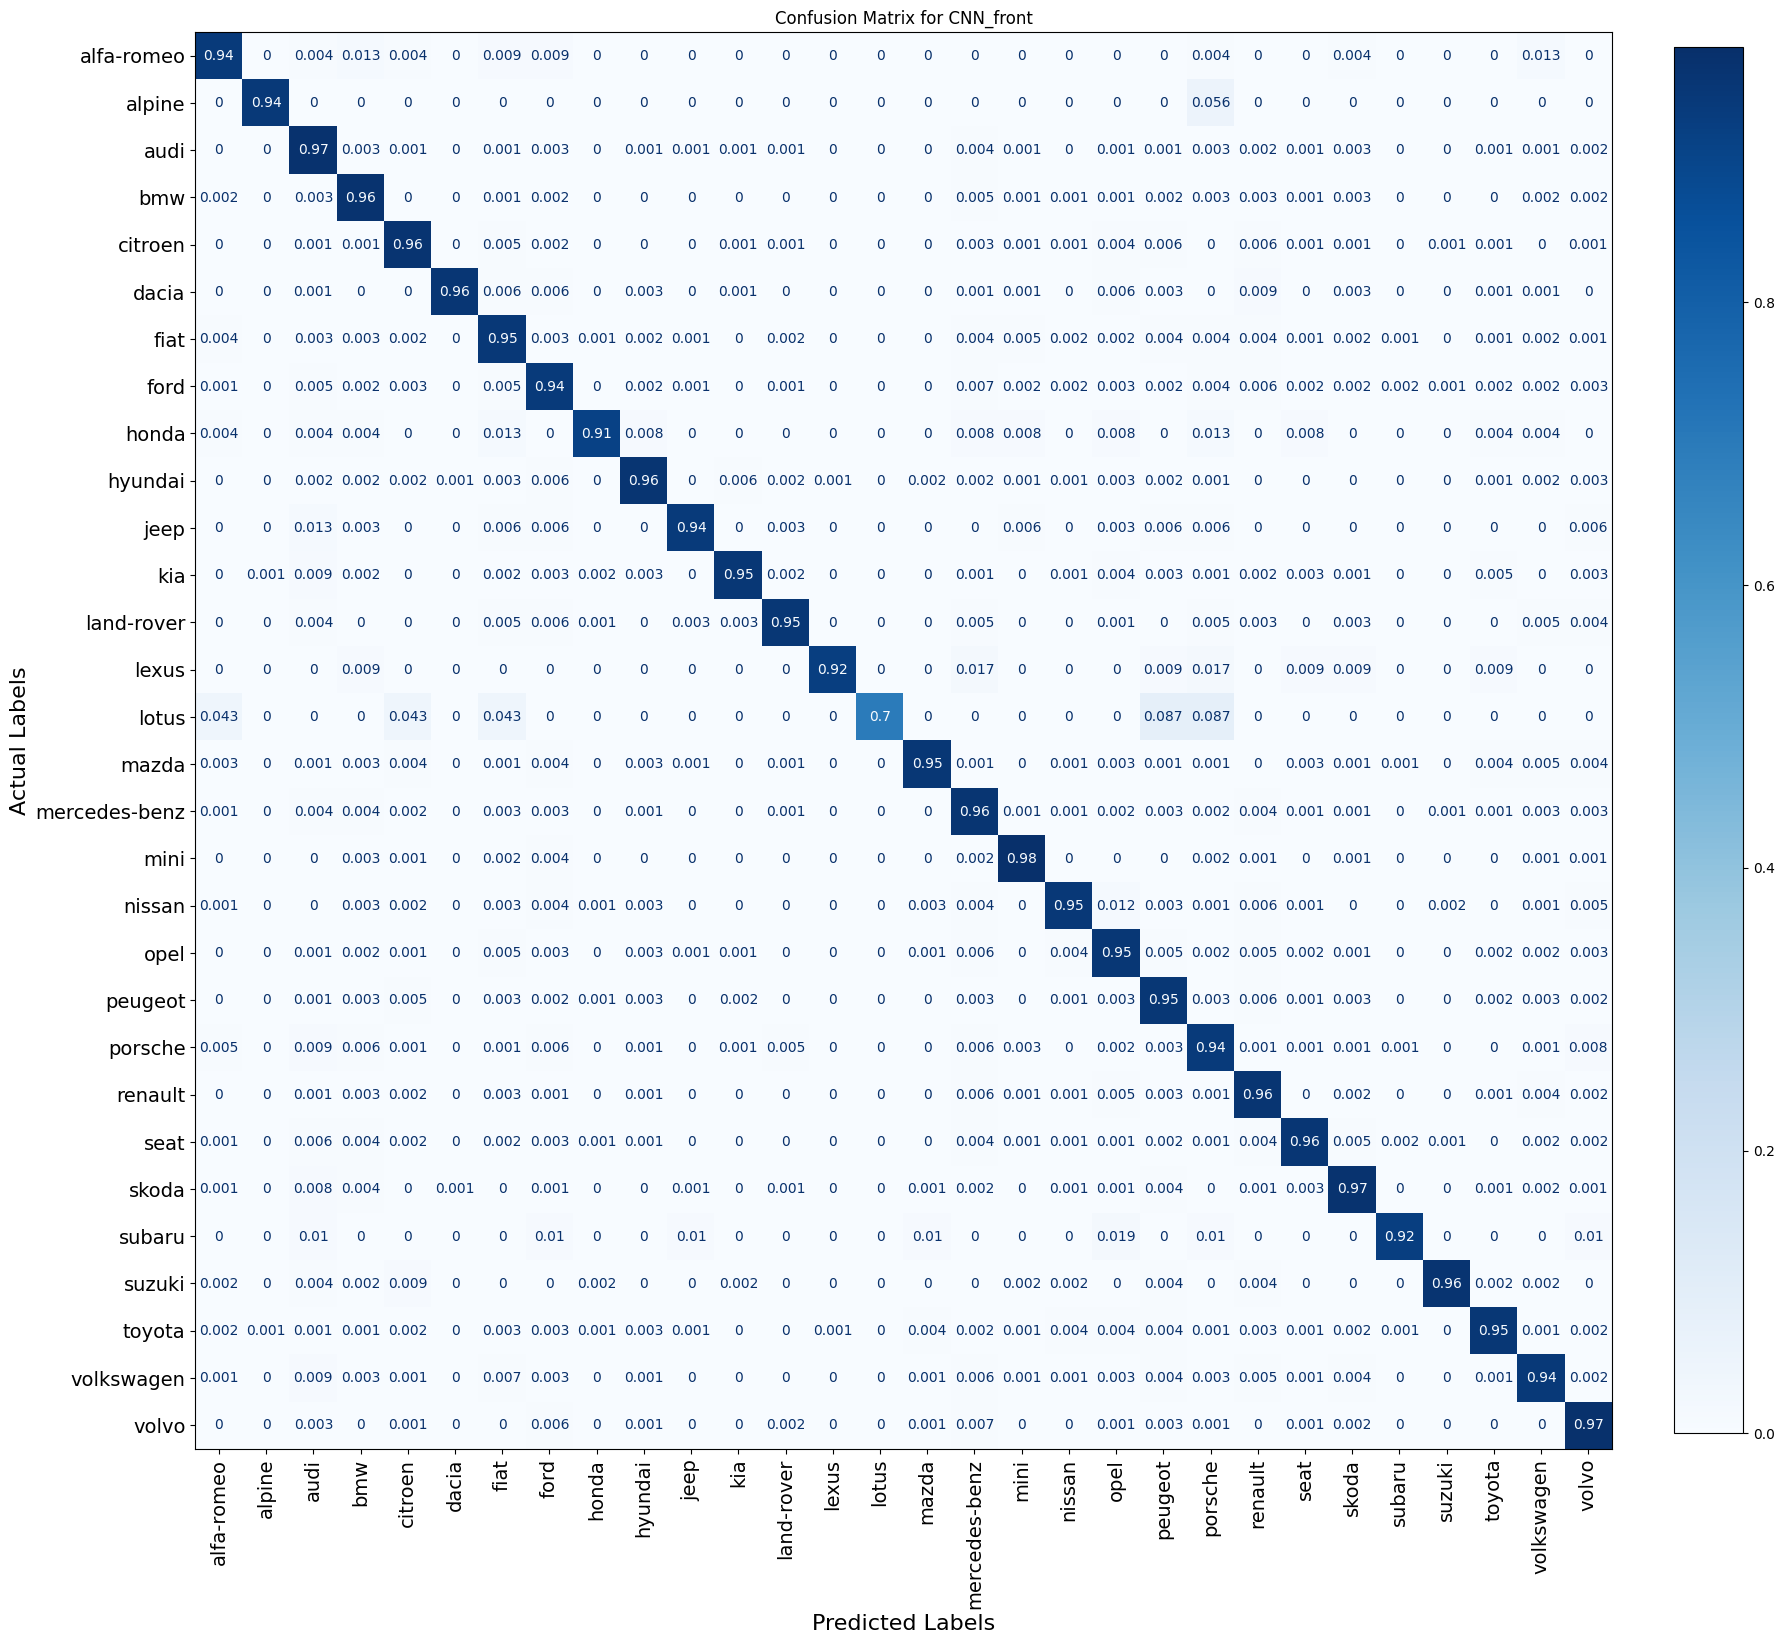

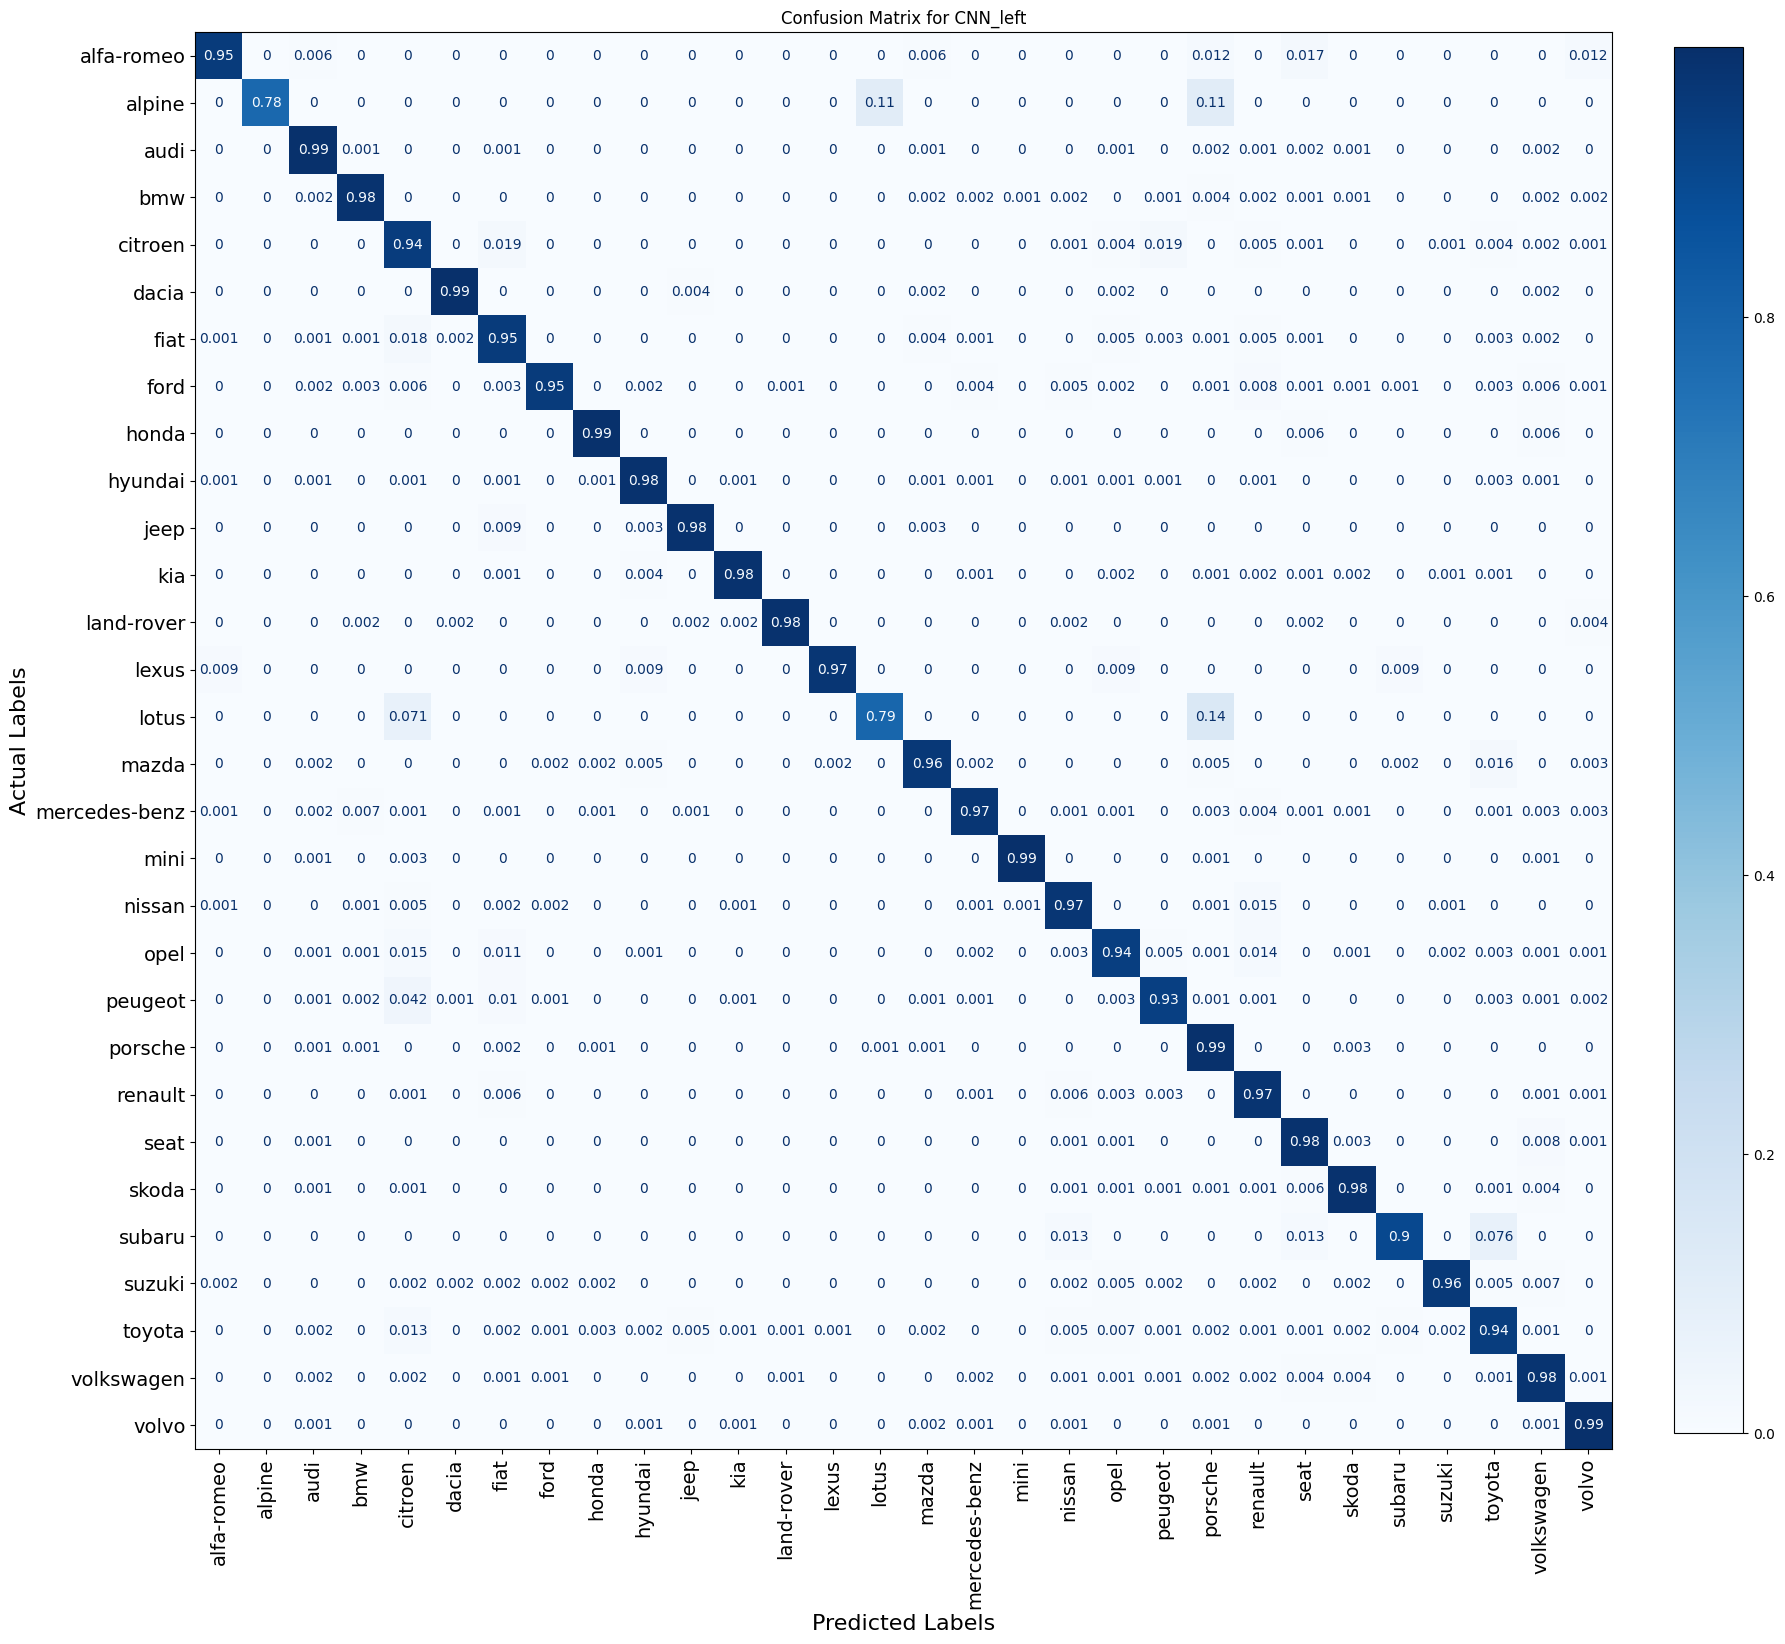

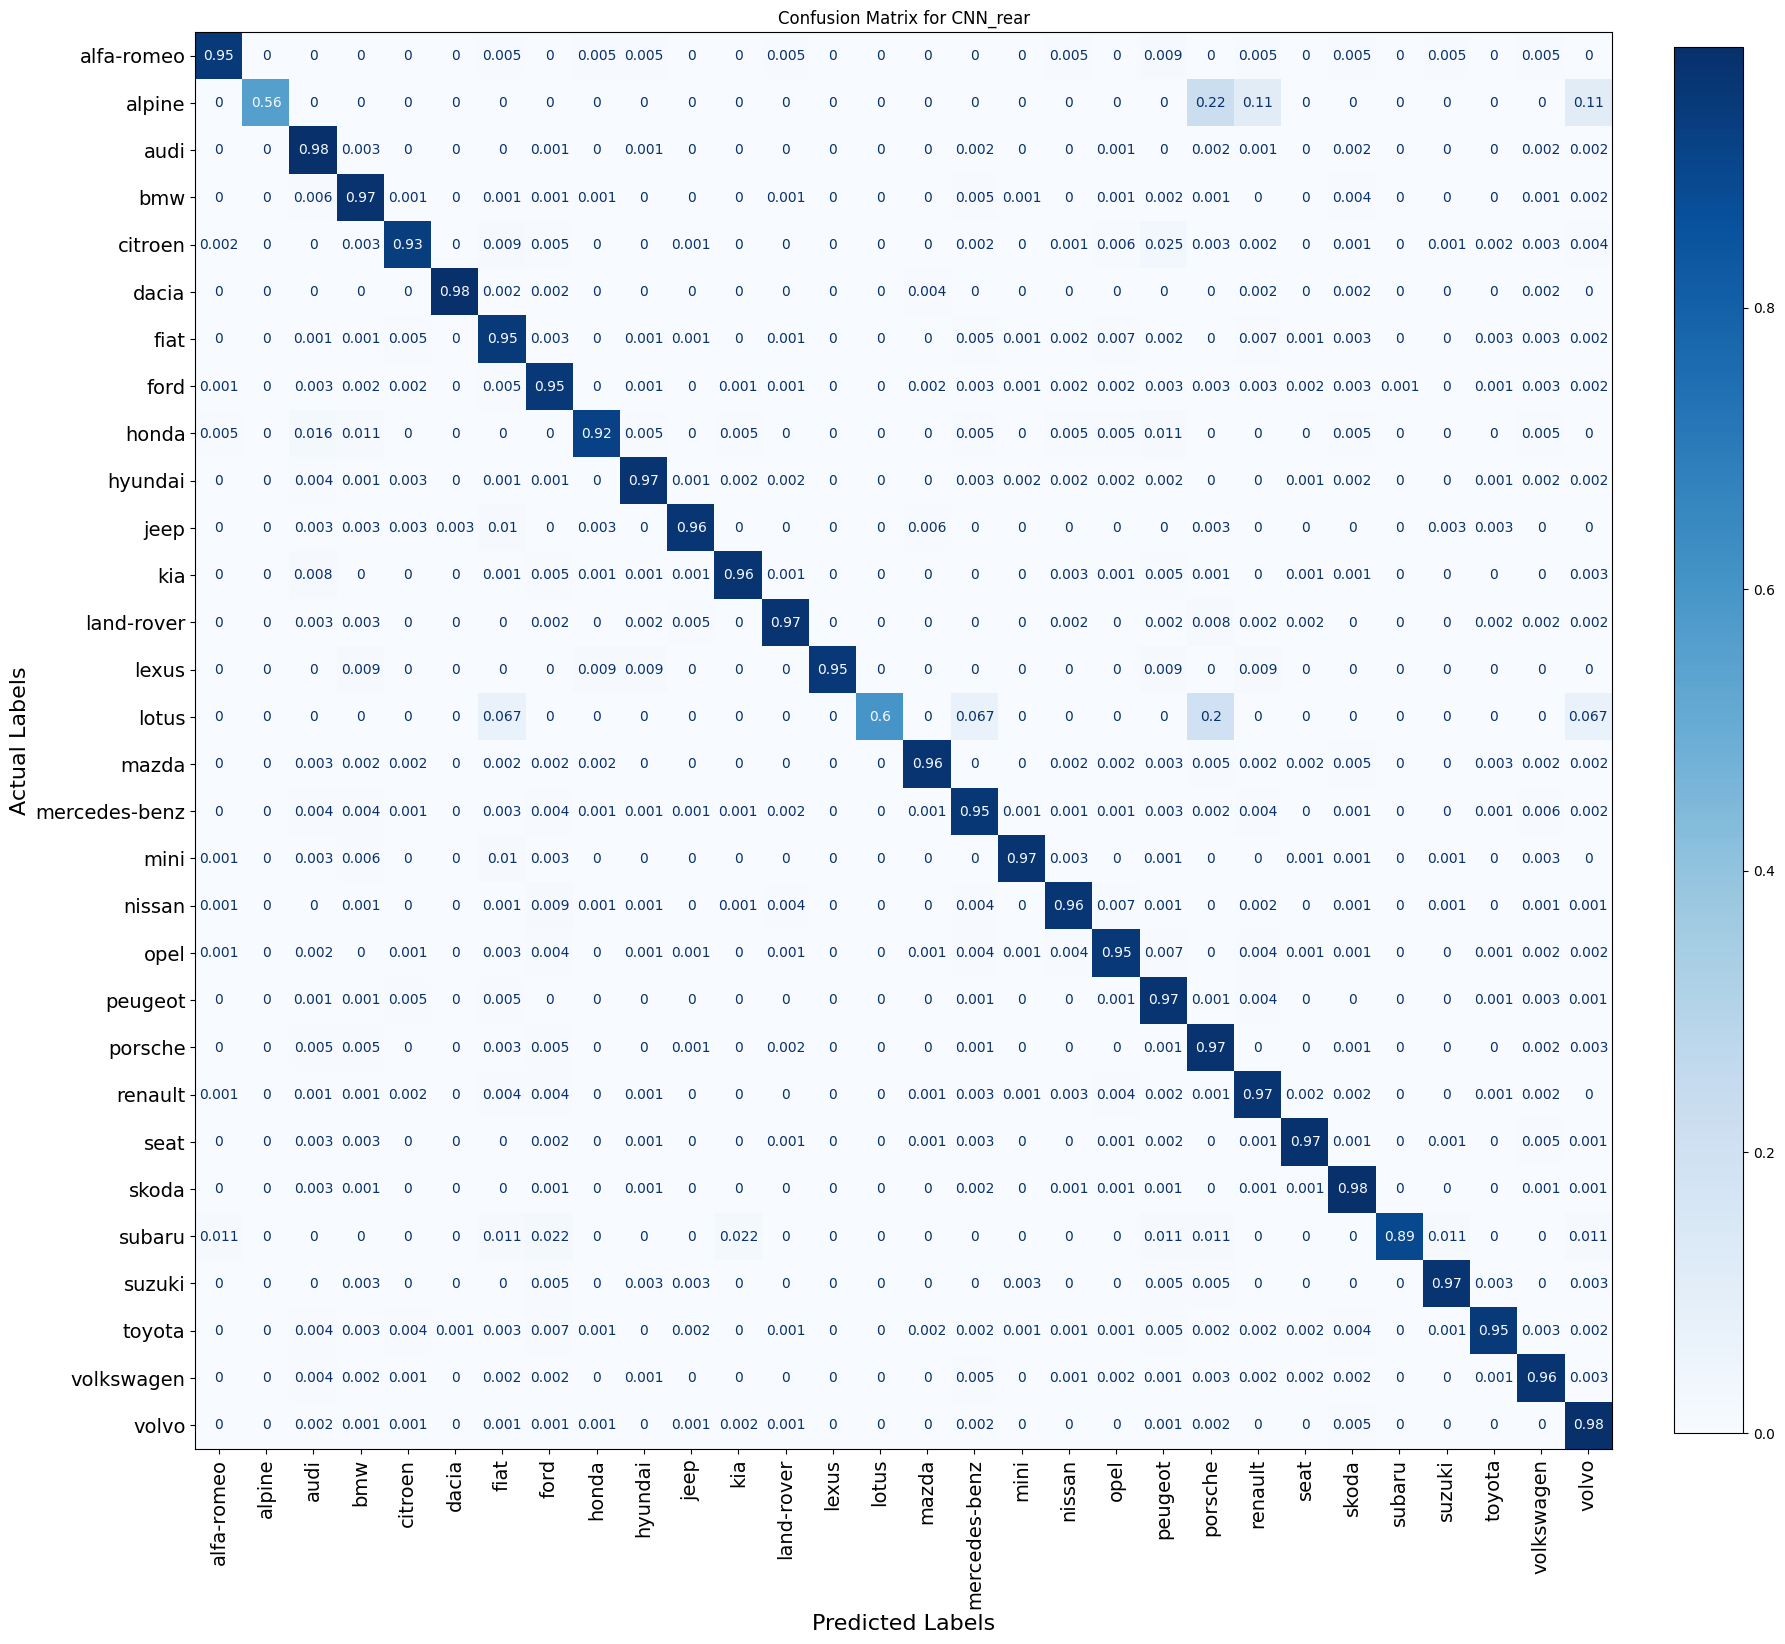

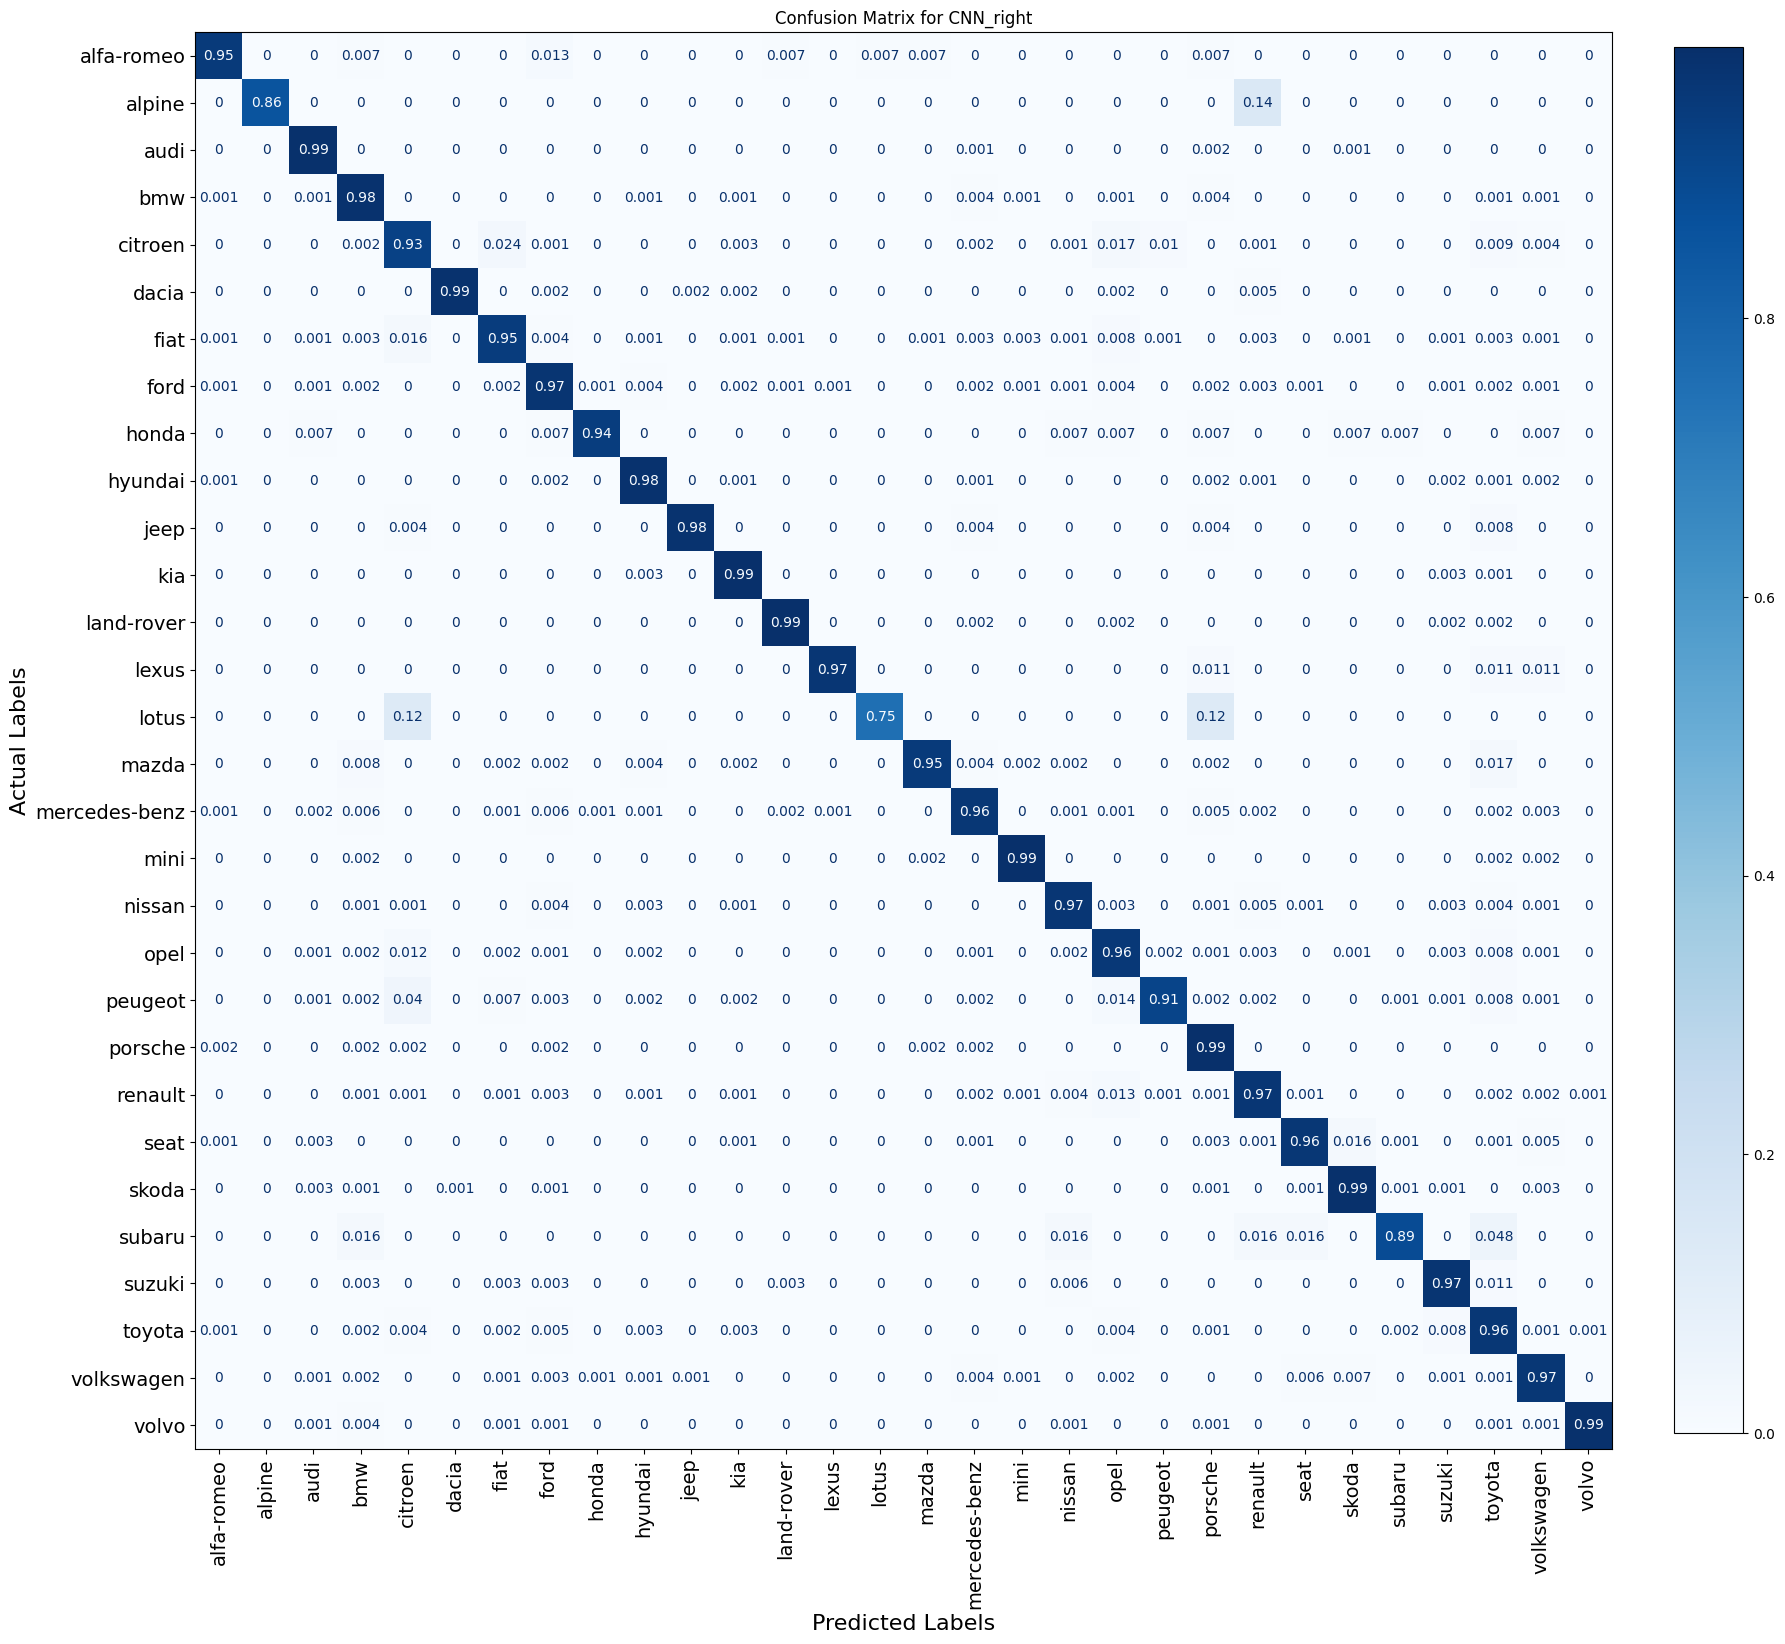

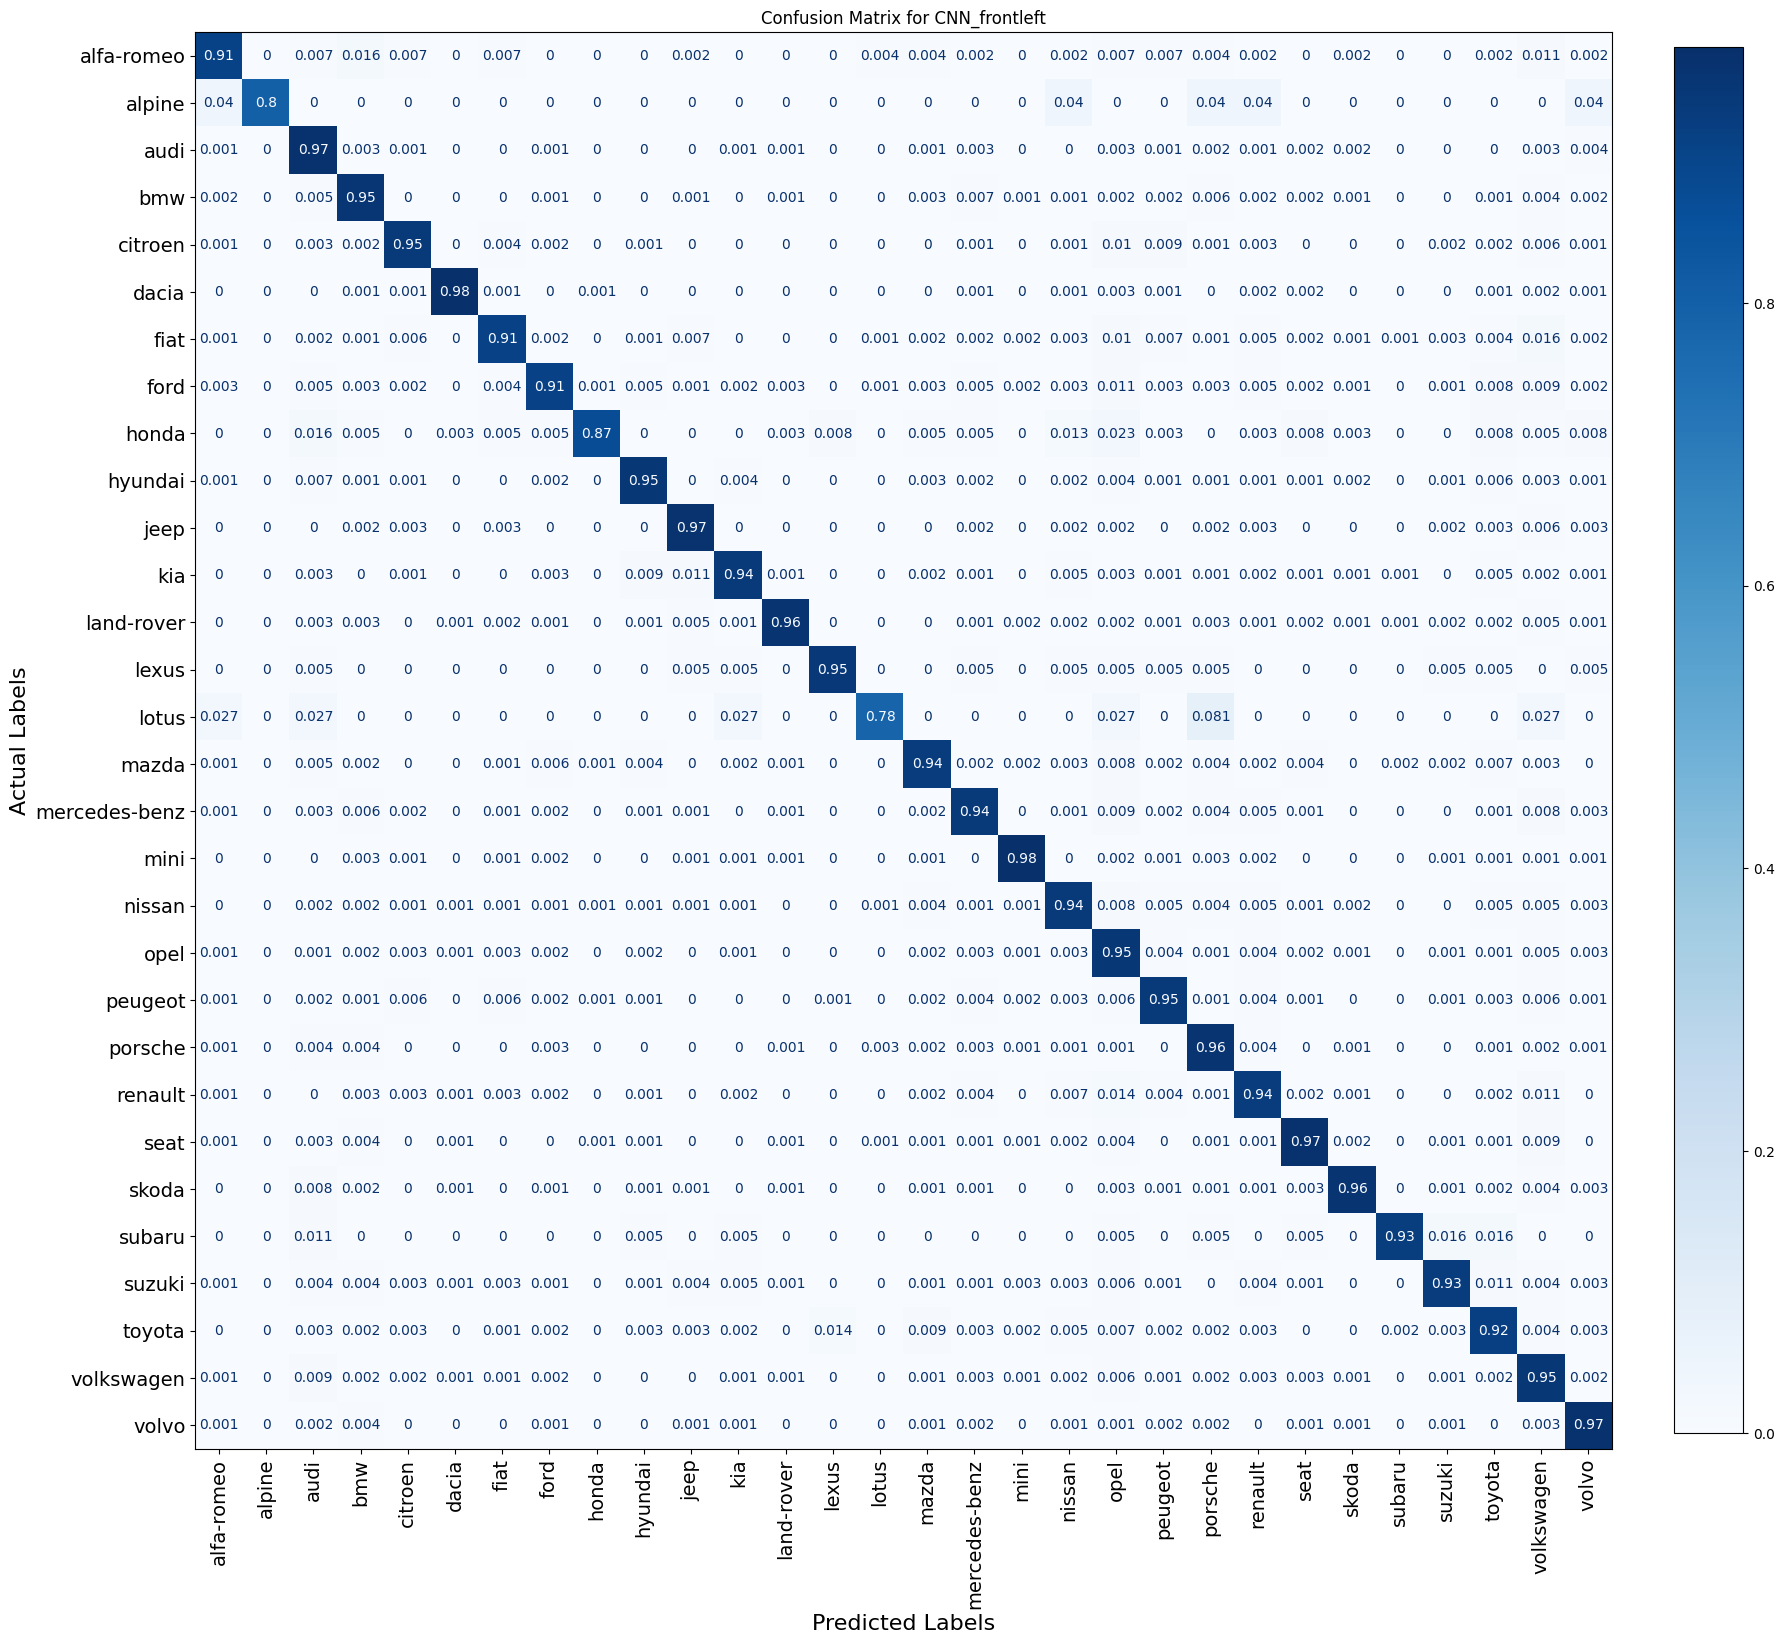

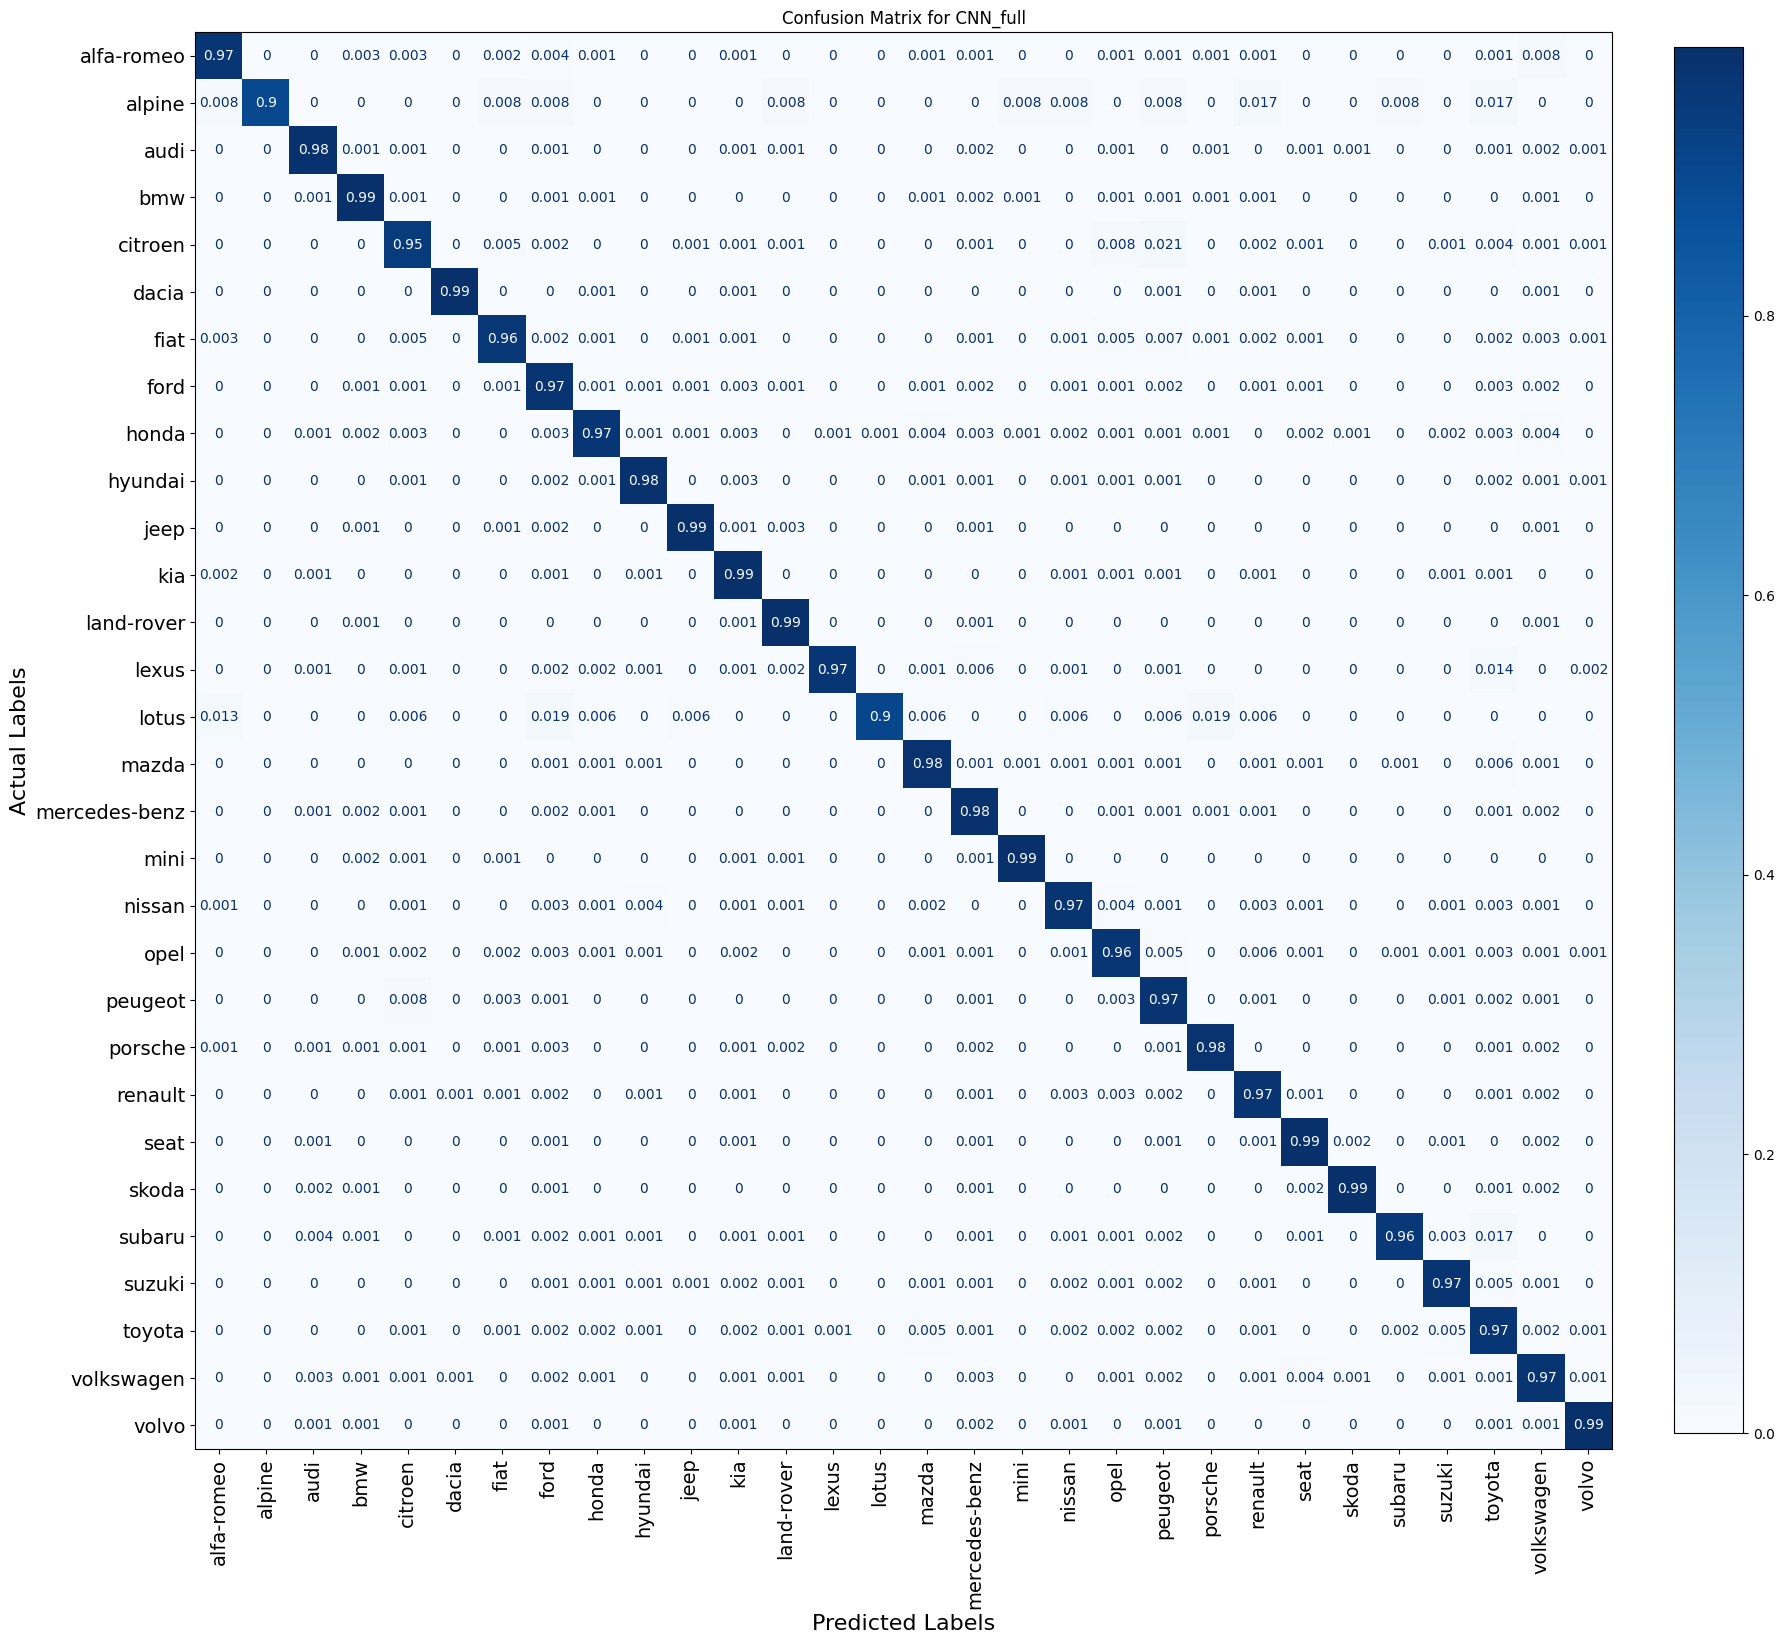

In [45]:
pooled_actuals = []
pooled_predicts = []
angle_metrics = {}
for profile, data in results.items():
    profile_name_short = profile.split('_')[0]
    for angle, valresults in data.items(): 
        encoded_prediction_labels = valresults['predicts']
        act = valresults['actuals']
        decoder =valresults['decoder']
        decoded_labels = decode_labels(decoder, encoded_prediction_labels)
        brand_names = decoder.values()
        pred = decoded_labels
        #POOL results to make an easy comparison of individual 
        #   training on angles vs one big model trained on all angles.
        if angle in validation_df.model_label.values:
            pooled_actuals.extend(act)
            pooled_predicts.extend(pred)
        cm = implot.make_cm(act, pred, brand_names)
        #TODO use the implot.quicplot method for quickmetrics outcome!

        angle_metrics[angle] = implot.quick_metrics(act, pred)
        cm.title(f"Confusion Matrix for {profile_name_short+'_'+angle}")
        cm.show()

So we got a lot of CMs now, let's maybe focus on a few first: 

#### 3.6.4.a: Equalized testset or not?
The front angle got trained twice, both models where trained on the same fully balanced trainset with 10.000 images per brand. The testset of the first test-unbalanced model was an actual representative sample of the real world; the testet of the testset-balanced model had the same amaount of instances, but each brand had the same amount of samples (using mean). So in that case, low-frequence brands hwere oversampled (unaugmented) e.g. Alpine. High-frequence brands were undersampled e.g. Volkswagen.

In [16]:
import matplotlib.pyplot as plt

data = results['CNN_based_models']
fua, fup = data['front']['actuals'], decode_labels(data['front']['decoder'], data['front']['predicts'])
fba, fbp = data['front_balanced']['actuals'], decode_labels(data['front_balanced']['decoder'], data['front_balanced']['predicts'])

def ez_compare(actuals, preds,):
    cm = implot.make_cm(actuals, preds, brand_names, embed=True)
    metrics = implot.quick_metrics(actuals, preds)
    #TODO use the implot.quicplot method for quickmetrics outcome!

    return cm, metrics

front_unbalanced_cm, front_unbalanced_metrics = ez_compare(fua, fup)
front_balanced_cm, front_balanced_metrics = ez_compare(fba, fbp)
full_metrics = {
    'balanced': front_balanced_metrics, 
    'ubalanced': front_unbalanced_metrics
    }

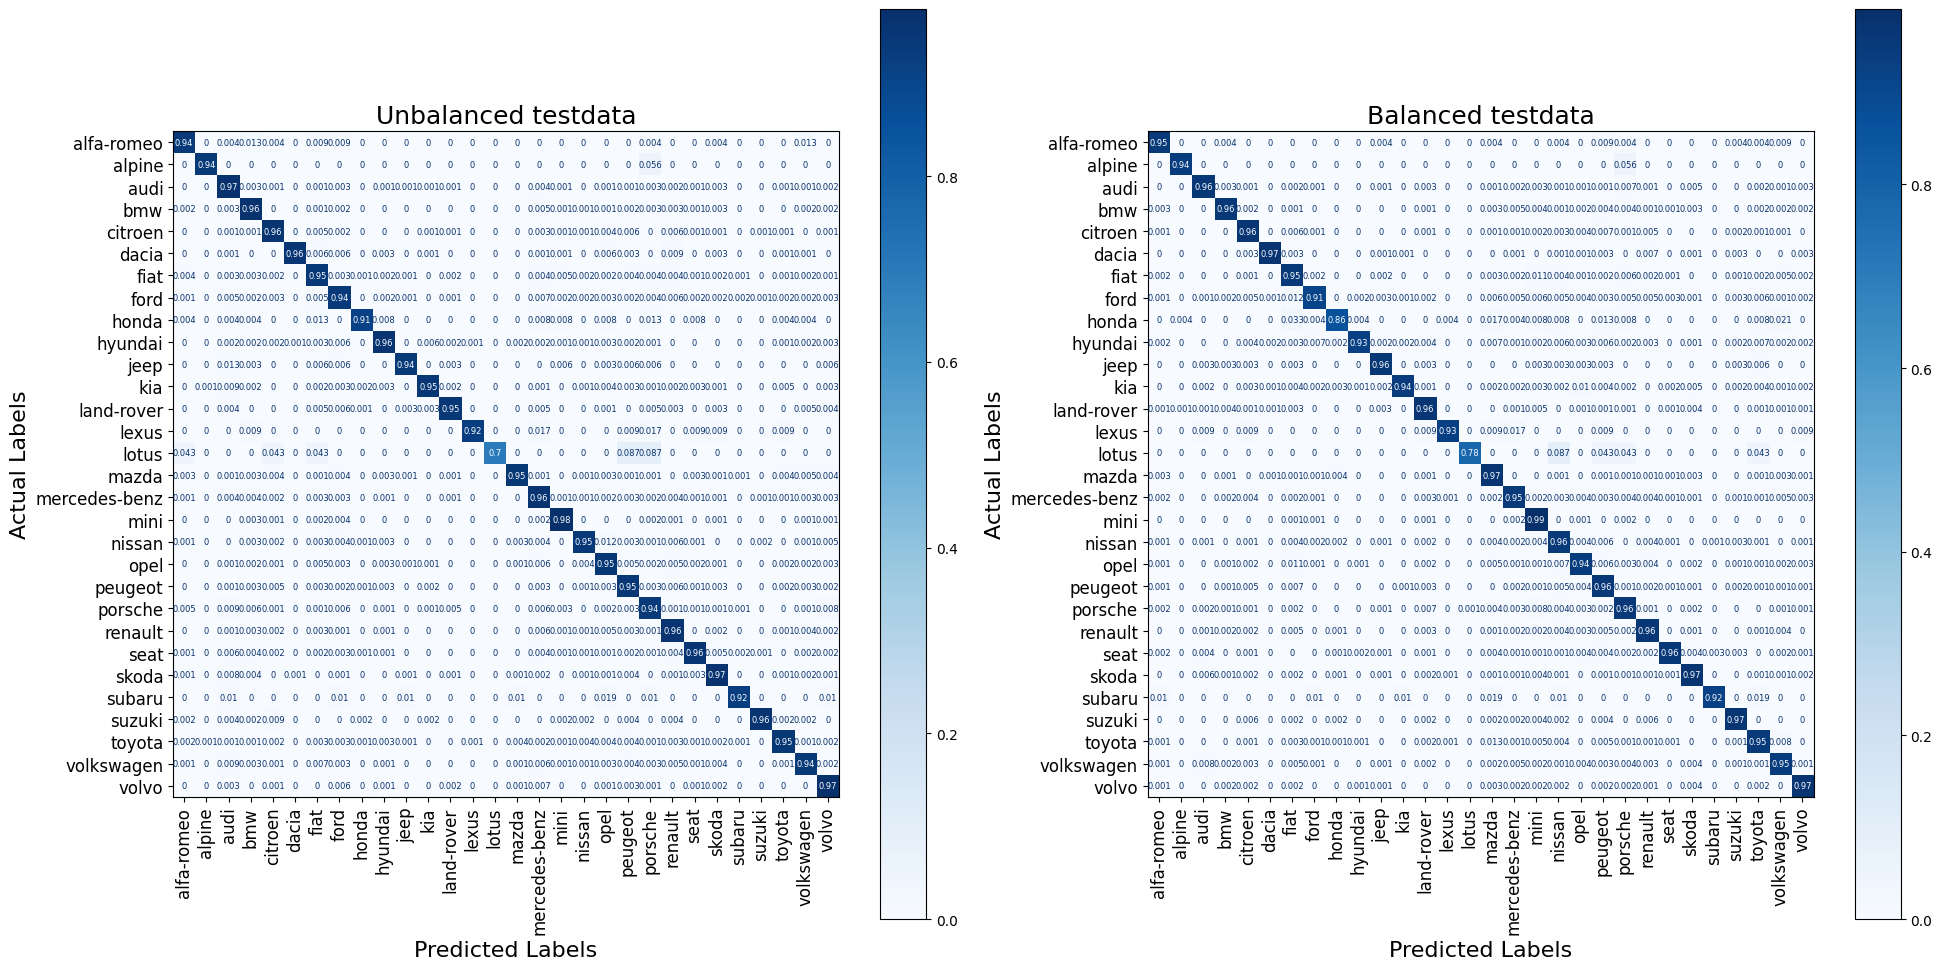

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()
for ax, cm_display, title in zip(
    axes,
    [front_unbalanced_cm, front_balanced_cm],
    ["Unbalanced testdata", "Balanced testdata"]
):
    cm_display.plot(ax=ax, cmap='Blues', colorbar=True)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Predicted Labels", fontsize=14)
    ax.set_ylabel("Actual Labels", fontsize=14)
    ax.tick_params(axis='x', labelrotation=90)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    for text in ax.texts:
        text.set_fontsize(6)
    ax.set_xticklabels(cm_display.display_labels, fontsize=12)
    ax.set_yticklabels(cm_display.display_labels, fontsize=12)

plt.tight_layout()

side by side comparison is not that clear from a glance, let's use the quickmetrics of both: 

And make a deltamatrix: 

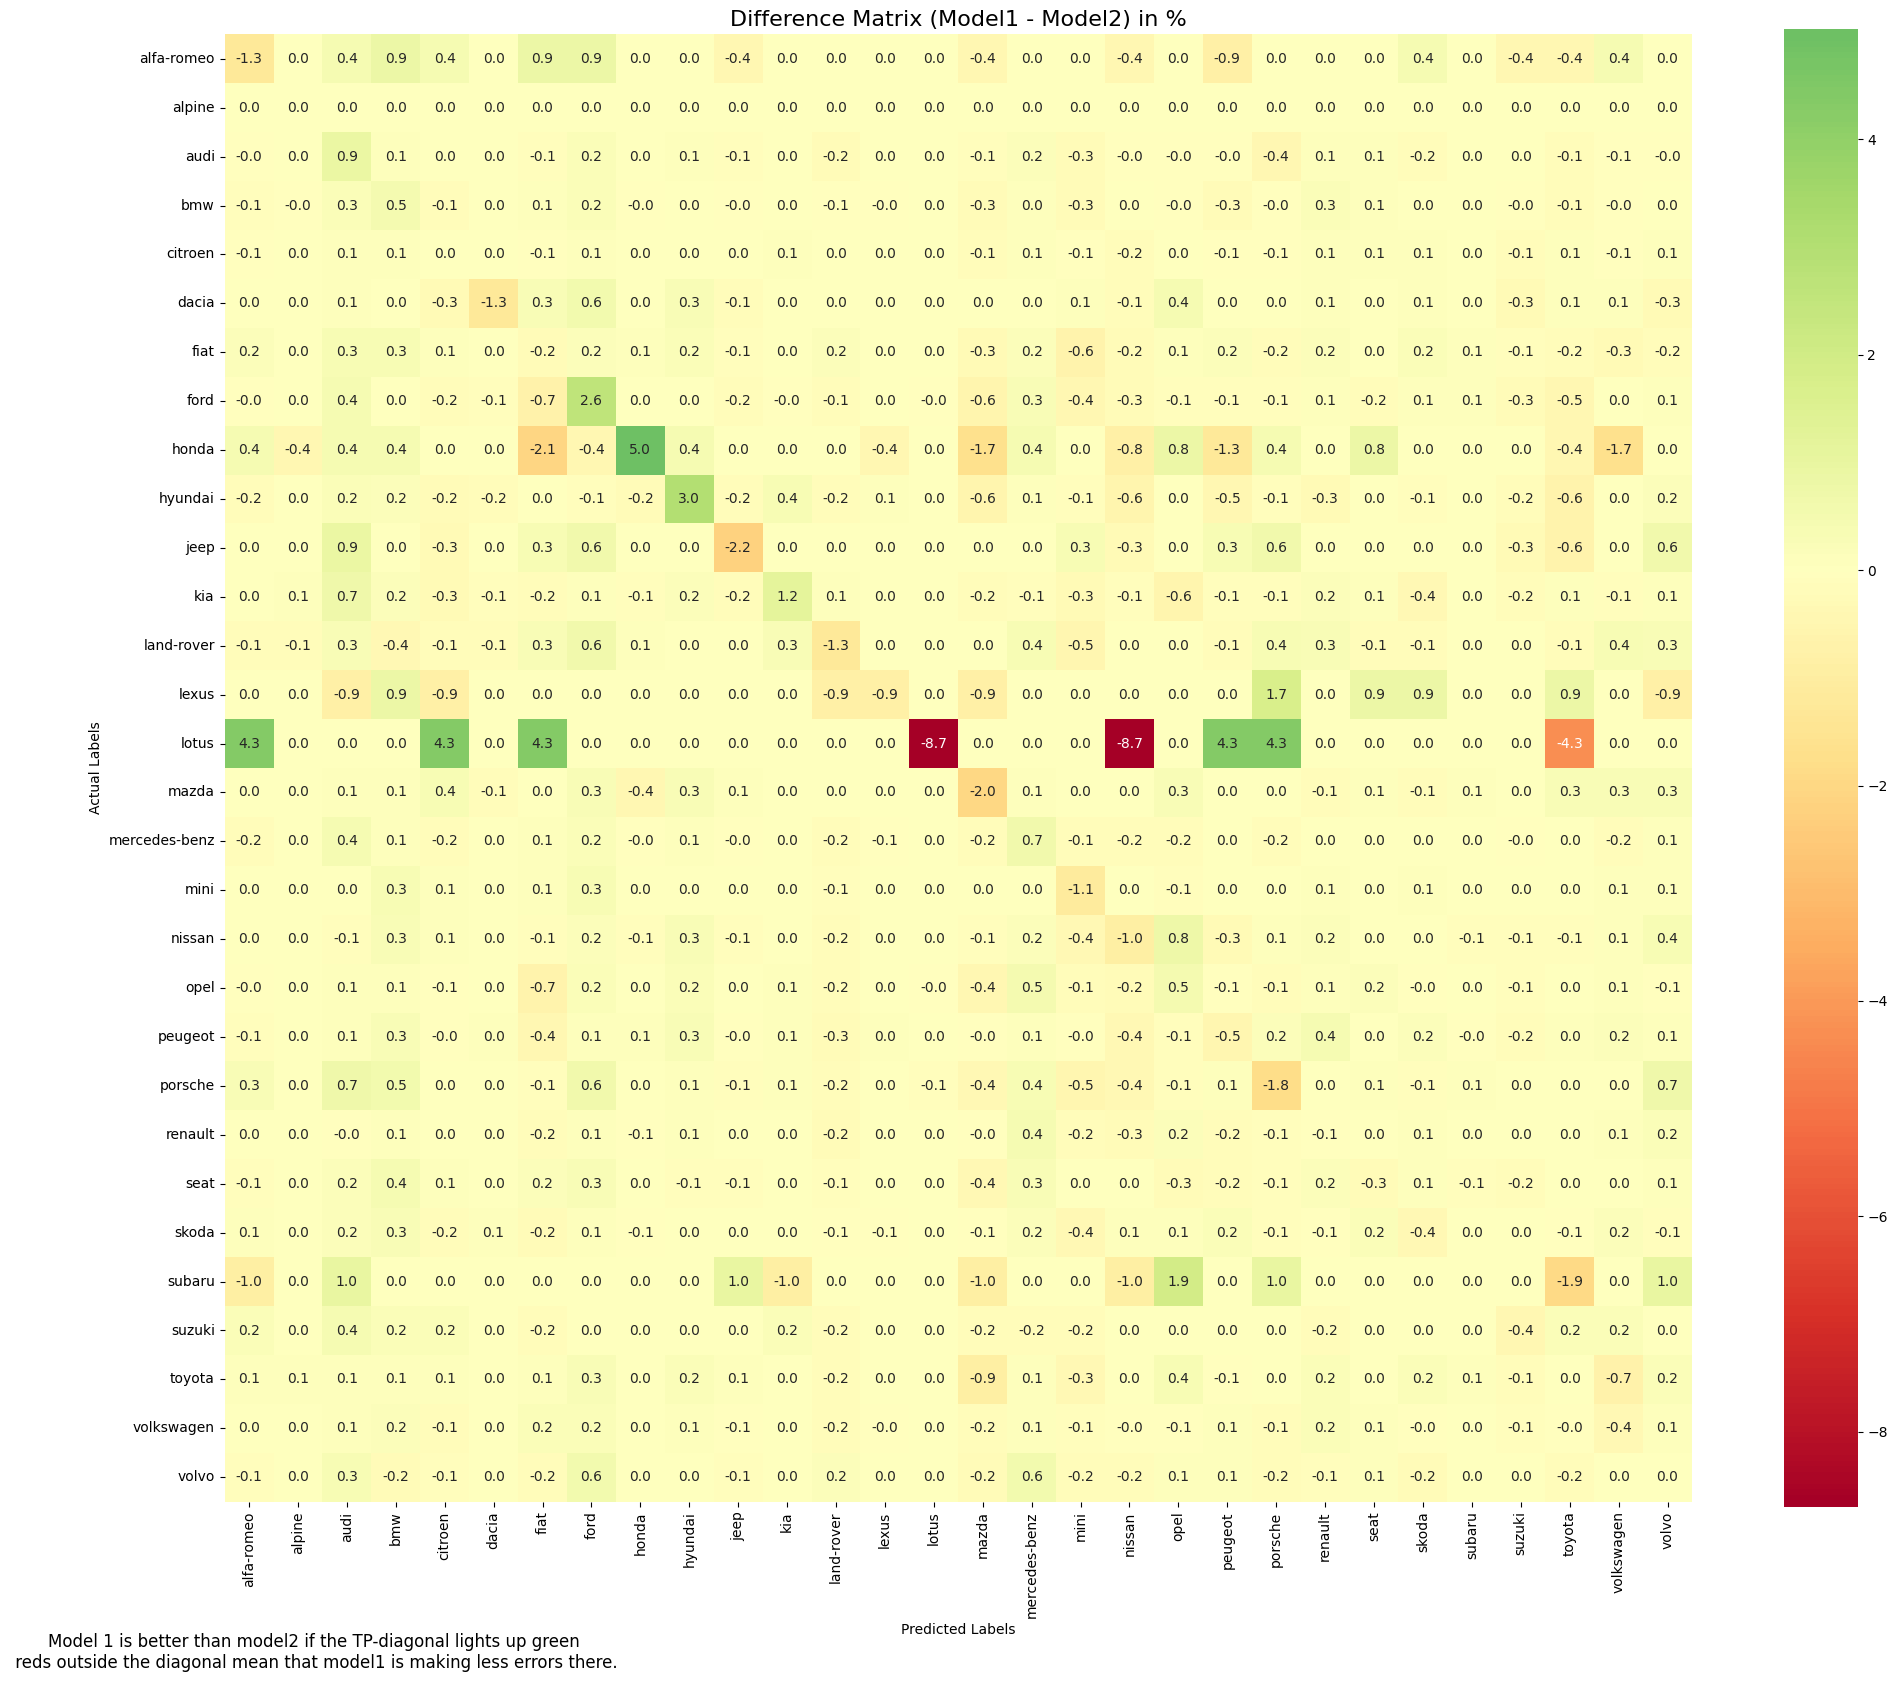

In [18]:
assert fua == fba #THIS IS THE SAME
implot.cm_delta(fup, fbp, fua, list(brand_names))#so we can use a deltaview
#the deltaview shows the absolute difference in %points not relative percentage. so a cell that goes from 0.9 to O.91 = will show as +1 (1percentpoint up.)

In the plots above model1 is the set trained without balancing out the test dataset; model2 was trained on exactly the same traindata, but with fully equalized testdata. 
- Green on the diagonal line = better performance of model1 than model 2
- Red on the diagonal line = better performance of model2 than model 1
- Green outside of diagonal line = better performance of model2 than model 1
- Red outside of diagonal line = better performance of model1 than model2

==> it's a close call; let's focus on the actual diagonal: 

In [ ]:
#Let's visualize that observation with a more clear plot. 
textObjects = {
    'title': 'Difference of balanced vs unbalanced testdata during training.',
    'xaxis_title': 'Accuracy difference in percentpoints',
    'yaxis_title': 'Brands'
}

implot.compare_model_accuracies(fup, fua, fbp, fba, list(brand_names),textObjects)

and let's now focus on the gathered metrics. 

In [20]:
fig = implot.plot_quick_metrics(full_metrics)
fig.update_layout(
    height=800,
    width=1400,
    title_text='Training front angle of dataset on balanced vs unbalanced testset (same traindata)',
    showlegend=False
)


The difference is negligeble, so this matters less than thought.

#### 3.6.4.b: Pooled angle prediction vs single model 
We've trained one big model on 2.4 million images (10.000 images per brand, per angle >> 10000x8x30) This was the traindataset; that same traindataset, could be broken down into 8 datasets of 10000 images per brand; these 8 datasets are the angled models and are trained to predict from a single only. 

Let's compare if pooling the results of 8 smaller models is betters than throwing all the data in a single model. 

In [21]:

data = results['CNN_based_models']
fa, fp = data['full']['actuals'], decode_labels(data['full']['decoder'], data['full']['predicts'])

full_cm, full_metrics = ez_compare(fa, fp)
pooling_cm, pooling_metrics = ez_compare(pooled_actuals, pooled_predicts)
full_metrics = {
    'pooled': pooling_metrics, 
    'full': full_metrics
    }

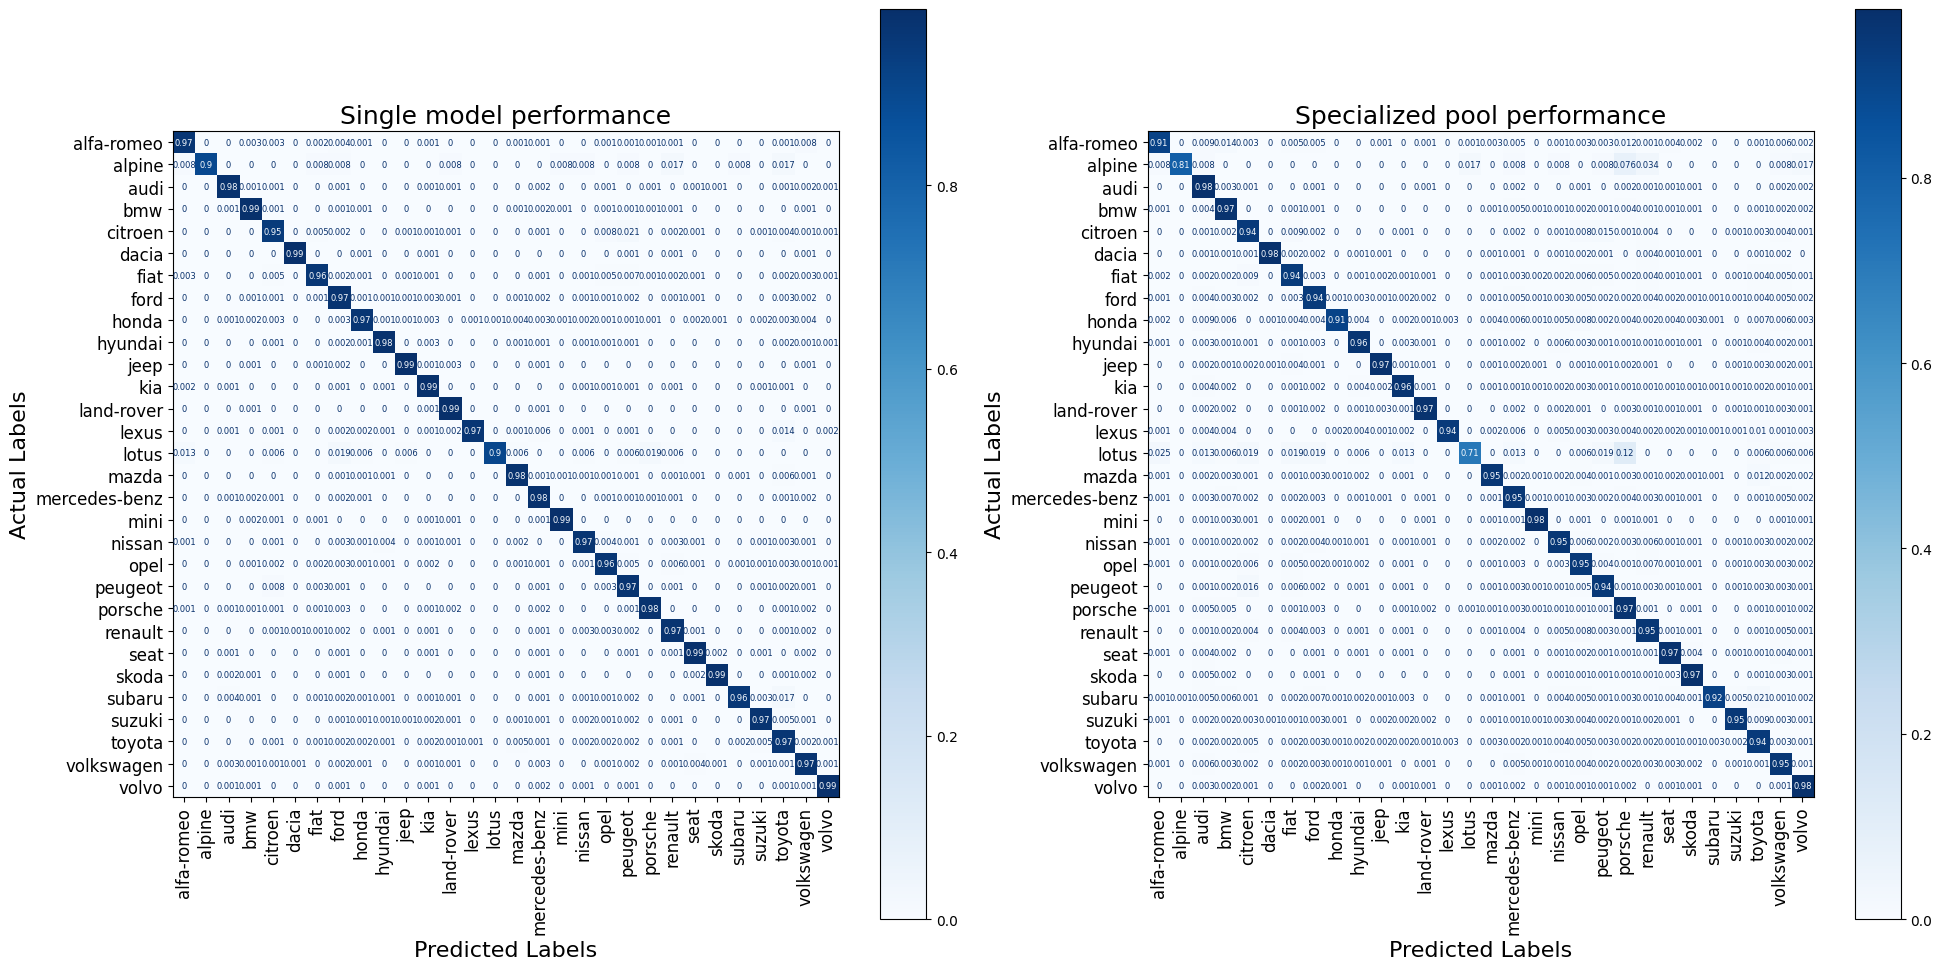

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()
for ax, cm_display, title in zip(
    axes,
    [full_cm, pooling_cm],
    ["Single model performance", "Specialized pool performance"]
):
    cm_display.plot(ax=ax, cmap='Blues', colorbar=True)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Predicted Labels", fontsize=14)
    ax.set_ylabel("Actual Labels", fontsize=14)
    ax.tick_params(axis='x', labelrotation=90)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    for text in ax.texts:
        text.set_fontsize(6)
    ax.set_xticklabels(cm_display.display_labels, fontsize=12)
    ax.set_yticklabels(cm_display.display_labels, fontsize=12)

plt.tight_layout()

Interesting observation: Look at the performance for low-frequency brands; less-occuring brands seem to to gain a lot by using the full model over a specialized angle model.

- Alpine
- Alfa Romeo
- Honda
- Lotus
- Subaru
- Lexus 

these are all brands on the right side of the frequency distribution chart; the are all performing better when inferring from a single model than pooling the results from 8 specialized models. 

In [46]:
#Let's visualize that observation with a more clear plot. 
textObjects = {
    'title': 'Difference of full model vs pooling 8 models',
    'xaxis_title': 'Accuracy difference in percentpoints',
    'yaxis_title': 'Brands'
}
implot.compare_model_accuracies(fp, fa, pooled_predicts, pooled_actuals, list(brand_names), textObjects)

We can even make a starker observation: There's no accuracy penalty for ANY brand in using the full model. This is good news for two reasons: 
1) We can take a completely unknown image and directly infer the brand from it without needing to infer the angle first (Faster end-to-end). 
2) Improving error-rates in angle detector is now a very very very low - to non-existent priority. 

In [27]:
fig = implot.plot_quick_metrics(full_metrics)
fig.update_layout(
    height=800,
    width=1400,
    title_text='Inferring from 8 pooled models (one per angle) versus a single model trained on all angles',
    showlegend=False
)


I was not expecting this: a single model with the full dataset is performing better than a model that combines the results of 8 pooled specializations. Keep in mind though, that the full model was trained on BALANCED angles. So you should not interpret this as "training angle recognition was  not useful". To make that assesment a model should be trained on 80000 images per brand randomly sampled without balancing out the angle!

Across all metrics, the full model performs better than pooled performance. A possible explanation for this could be that errors in the angle-detection phase have a more pronounced effect if you only expect angle X; whereas a model that's open to all angles will see this as a (very slight) class imbalance. 

Performance wise, the full model is better than 8 models, each trained on a specific angle. HOWEVER, trainingswise there's a huge difference and we should be aware of this: 
- the angle-specific models CAN be trained in parallel on COLAB: copy the 3.3 notebook 8 times, configure each notebook to run training on a specific angle and you're done.
- The full model cannot be trained in parallel! 

The cost to train 8 specialized models was also lower (consuming ca. 330 Tokens on Google Colab with the L4 GPU High-Ram environment.). The full model was trained until the remaining 370 tokens where used up; at the time it reached the end of the available credits, the model was already in the final LR-phase but it hadn't met all criteria yet for Early stopping (so it could've improved a few promiles more). 

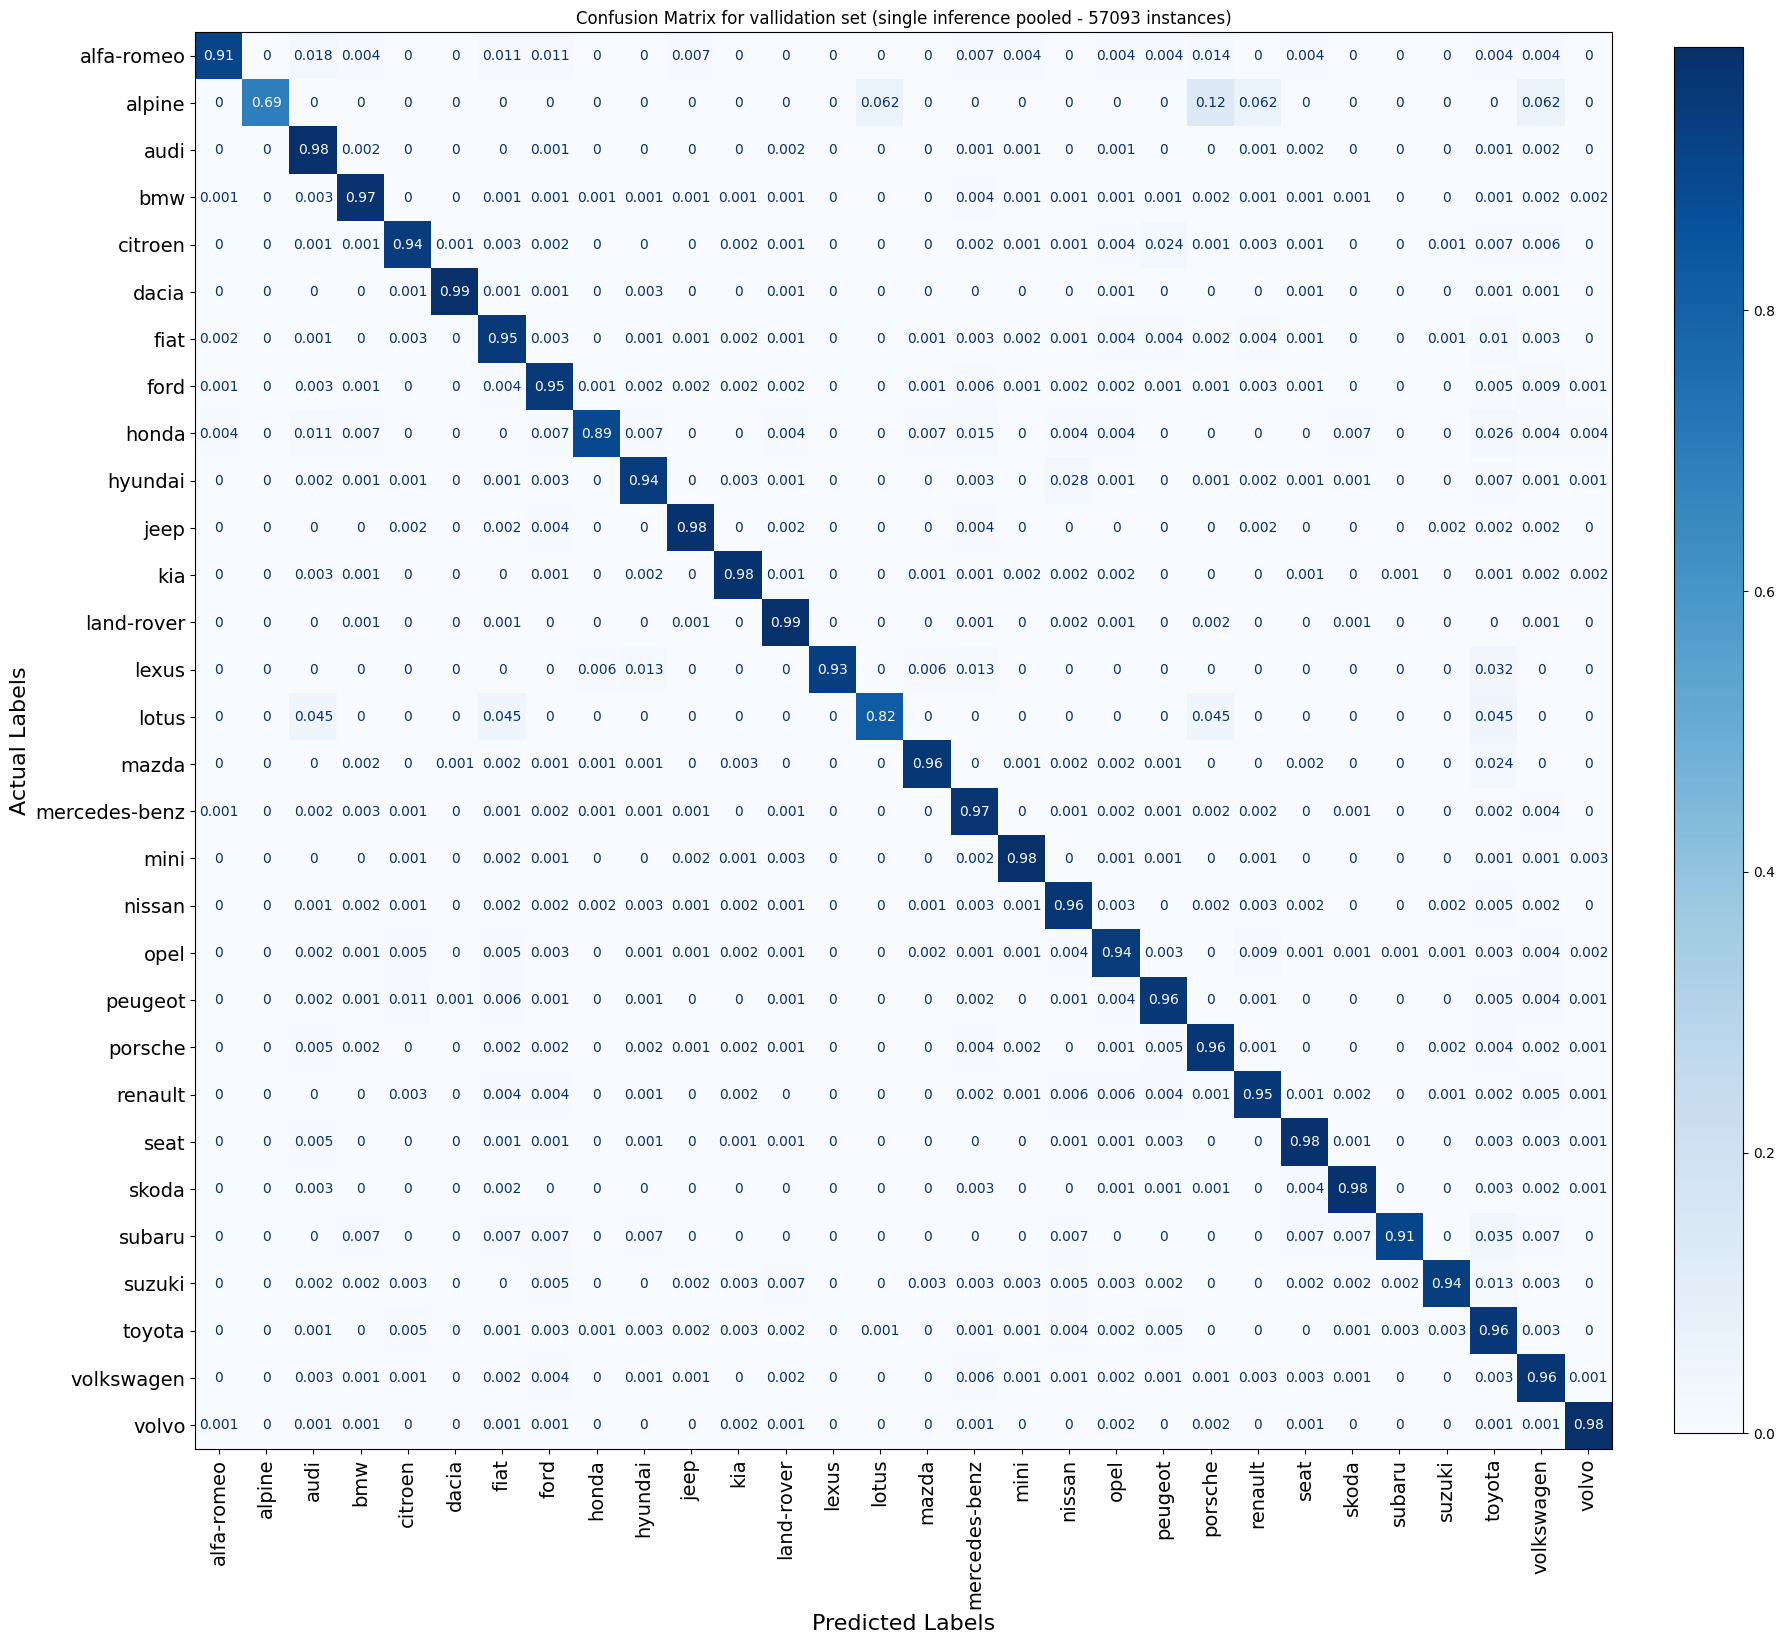

In [39]:
# Pooled single inference performance: 
cm = implot.make_cm(pooled_actuals, pooled_predicts, brand_names)
cm.title(f"Confusion Matrix for vallidation set (single inference pooled - {len(pooled_actuals)} instances)")
cm.show()


#TODO use the implot.quicplot method for quickmetrics outcome!
angle_metrics['pooled'] = implot.quick_metrics(pooled_actuals, pooled_predicts)


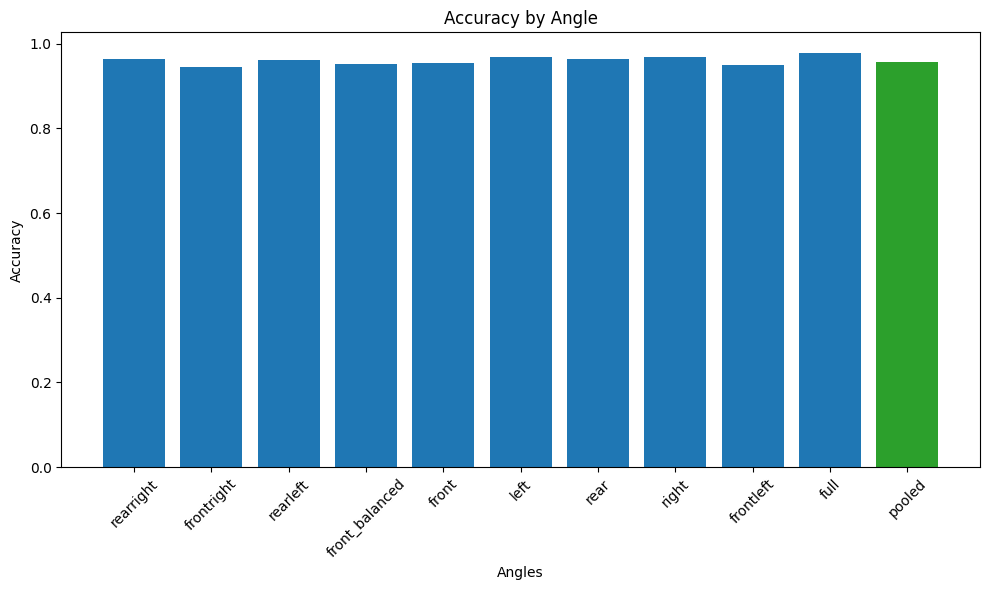

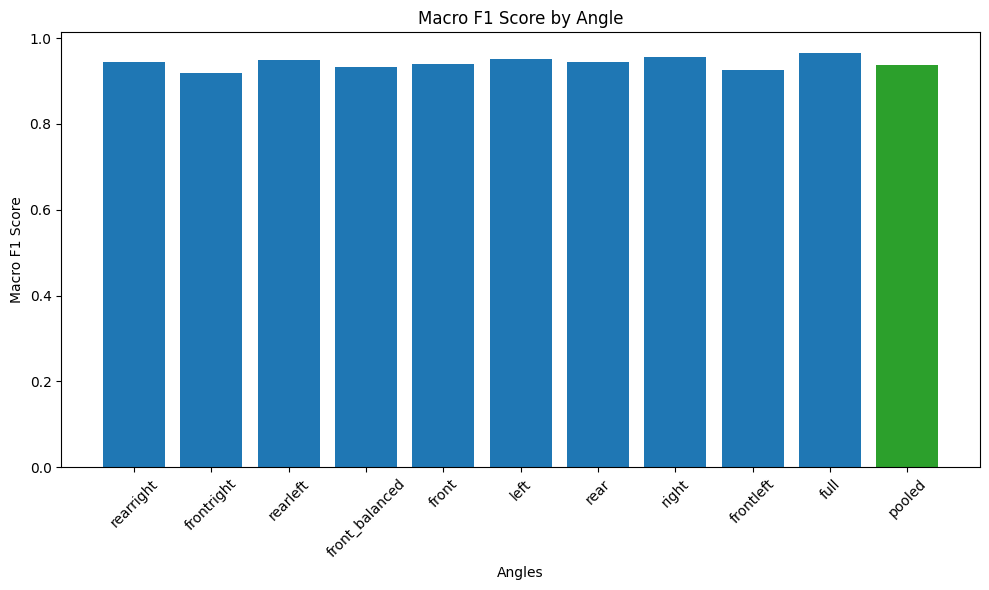

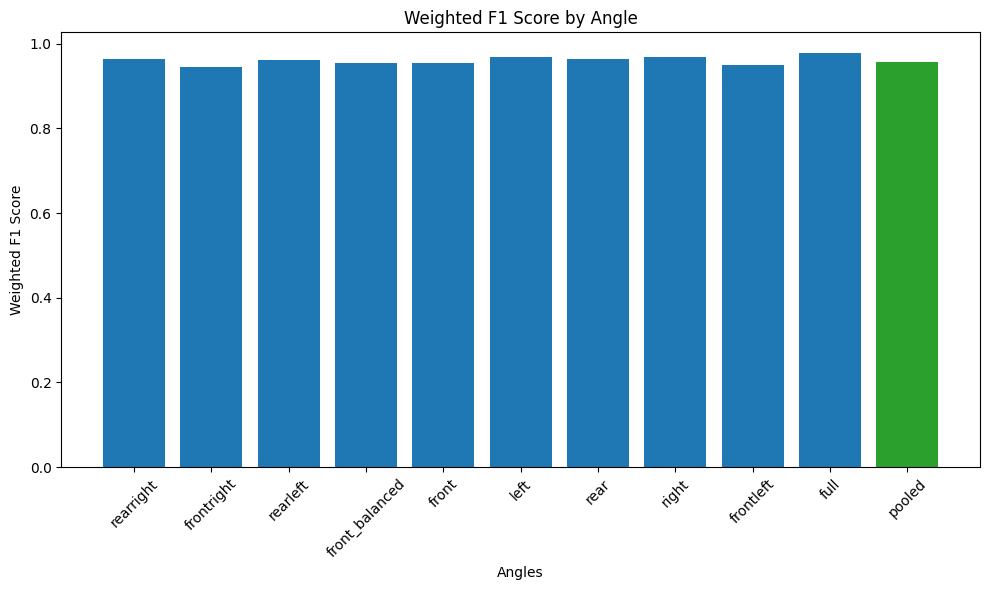

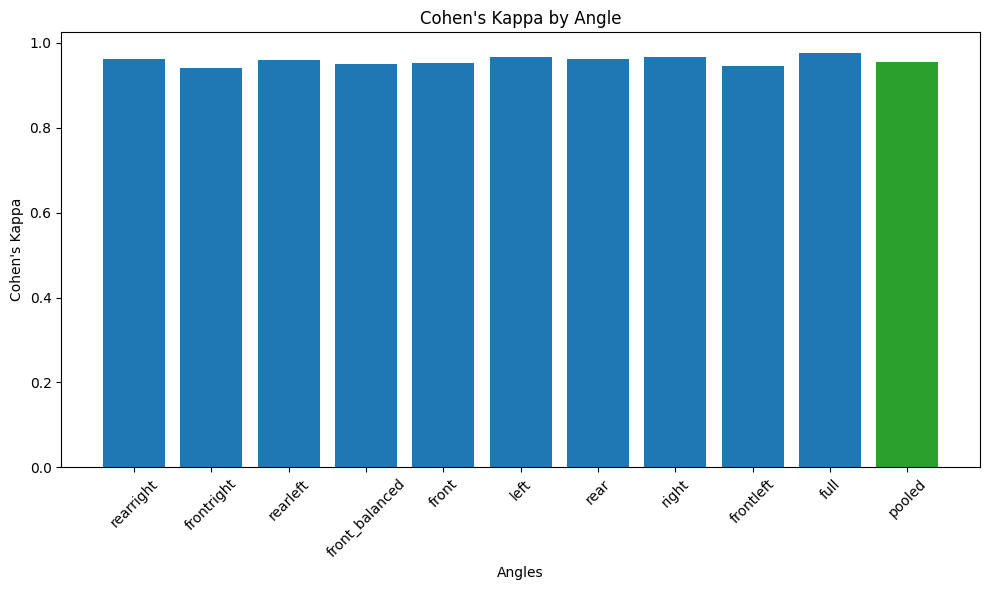

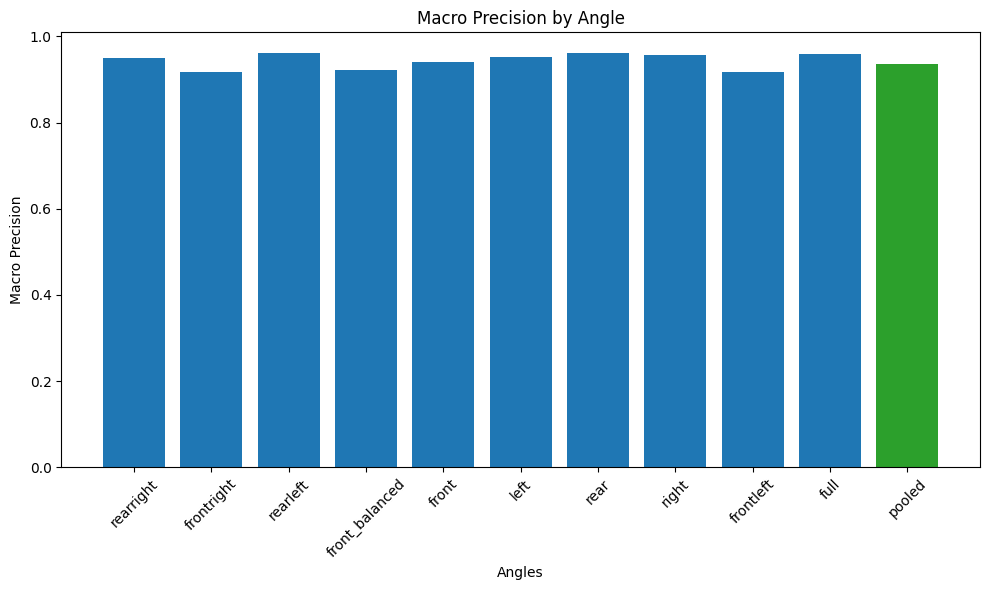

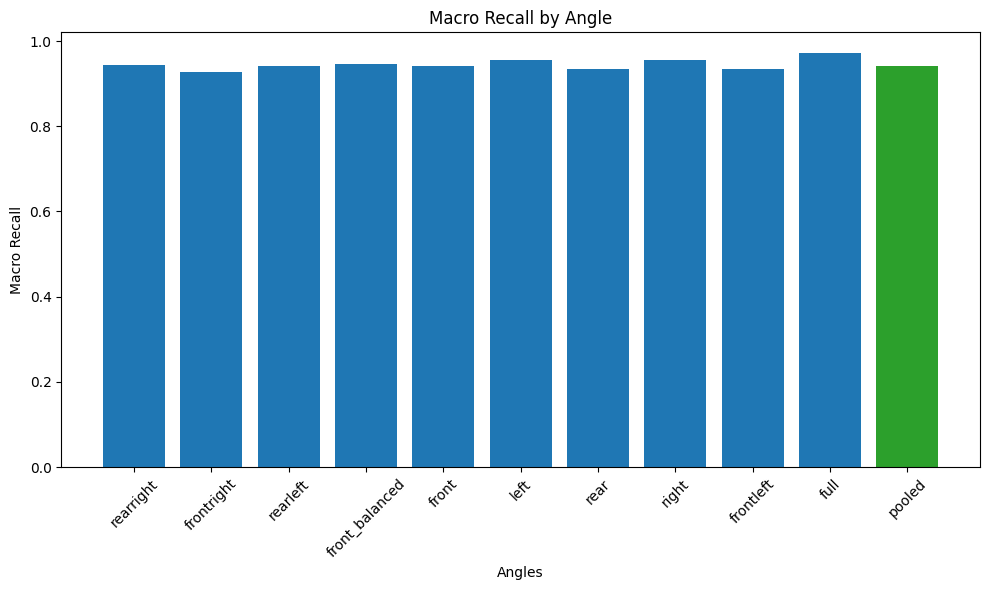

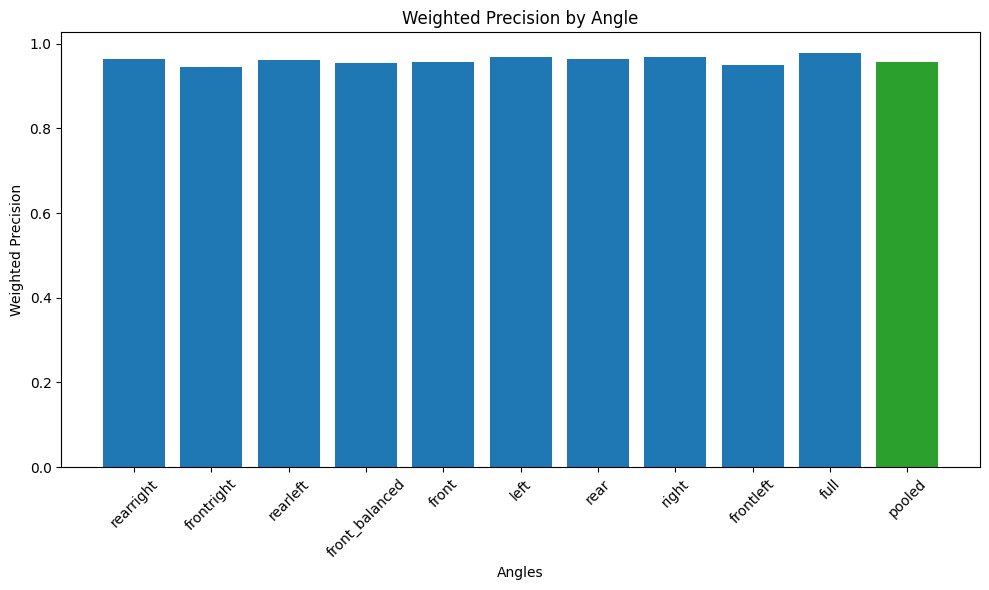

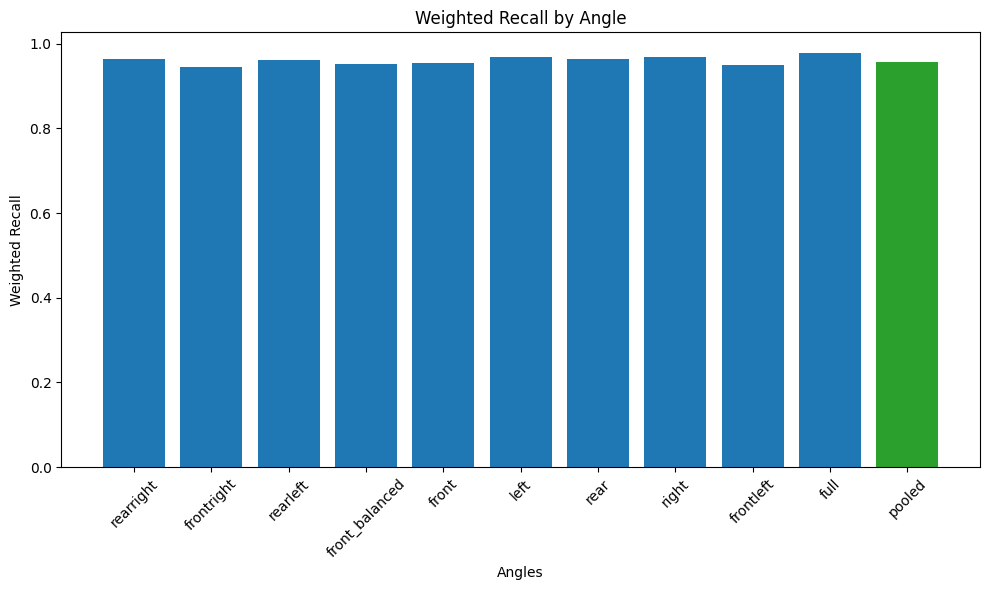

In [29]:
angles = list(angle_metrics.keys())
metrics = angle_metrics[angles[0]].keys()
color = ['tab:blue'] * (len(angles) - 1) + ['tab:green']
for metric in metrics:
    values = [angle_metrics[angle][metric] for angle in angles]
    plt.figure(figsize=(10, 6))
    plt.bar(angles, values, color=color)
    plt.title(f'{metric} by Angle')
    plt.xlabel('Angles')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [33]:
print(angle_metrics['pooled']['Accuracy'])
print(angle_metrics['full']['Accuracy'])


0.9572245847126128
0.9777778334640569


Using eight specialised models based on a CNN gave an **accuracy** across the full validation set of **95,72%**; using a single CNN-based model of EQUAL angle distributation gave us **97.778%** accuracy.

## 3.6.5 Performance assessment of angle based brand models (all 8 infer)
all of the json dicts are actually the same which was to be expected using label_encoder (alhpabetical sorting is done there), so in this step we can relax and not worry about different labels being outputted by the model for different models. 

In [ ]:
predictions_all = {}
actuals_all = validation_df.brand.to_list()

In [ ]:
PBS = 1024  # TODO get rid of this fucker

all_infer_filename = 'all_infer.json'
all_infer_filepath = os.path.join(INFER_PATH, all_infer_filename)
if READ_INFER and os.file.exists(os.path.join(INFER_PATH, all_infer_filepath)): 
    single_infer_predicts = json.load(all_infer_filepath)
    print('INFERENCE RESULTS READ FROM DISK')
else: 
    for angle_folder in os.listdir(MODELDIR): 
        dir = os.path.join(MODELDIR, angle_folder)
        dircontent = os.listdir(dir)
        print(f'Starting predictions for {angle_folder}         ')
        model = cnn_helpers.load_one_model(dir)
        predictions_all[angle_folder] = []
        l = len(validation_df)
        for i in range(0, l, PBS):
            print(f'{i} of {l} ({i/l*100}%)', end='\r')
            batch_df = validation_df.iloc[i:i + PBS]
            X_val_images = []
            for _, row in batch_df.iterrows():
                coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
                image = cnn_helpers.preprocess_image(row['abs_path'], CROP, coords, SHAPE)
                X_val_images.append(image)

            X_val_images = np.array(X_val_images)
            batch_predicts = model.predict(X_val_images, verbose=0)
            predictions_all[angle_folder].extend(batch_predicts)

        # Predict for the current batch
        batch_predicts = model.predict(X_val_images, verbose=0)
        predicts.extend(batch_predicts)
        actuals.extend(y_targets)
    if STORE_INFER: 
        new_predictions_all = {}
        for k, v in predictions_all.items(): 
            new_predictions_all[k] = [arr.tolist() for arr in v]
        file_io.dict_to_json_file(
            new_predictions_all, 
            INFER_PATH, 
            all_infer_filename
        )

In [ ]:
with open(all_infer_filepath) as f:
    json_predicts_from_file = json.loads(f.read())

In [ ]:
max_certain_predictions = []
prediction_value_count = len(predictions_all[list(predictions_all.keys())[0]])
for i in range(prediction_value_count): 
    v = []
    for angle in predictions_all: 
        v.append(predictions_all[angle][i])
    idx = np.argmax(np.array(v).max(axis=1))
    prediction = np.argmax(v[idx])
    max_certain_predictions.append(prediction)
decoded_max_certain = [decode_labels[list(predictions_all.keys())[0]][i] for i in max_certain_predictions]


In [ ]:
all = implot.make_cm(actuals_all, decoded_max_certain, decode_labels[list(predictions_all.keys())[0]])
all.title('Hard voting of all eight inferred angle models')
all.show()

In [ ]:
all_infer_metrics = quickrun_metrics(actuals_all, decoded_max_certain)

In [ ]:
#TODO: make this code less retarded
df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1 Score', 'Weighted F1 Score', "Cohen's Kappa"],
    'Pooled': [angle_metrics['pooled']['Accuracy'], angle_metrics['pooled']['Macro F1 Score'],
               angle_metrics['pooled']['Weighted F1 Score'], angle_metrics['pooled']["Cohen's Kappa"]],
    'All': [all_infer_metrics['Accuracy'], all_infer_metrics['Macro F1 Score'],
            all_infer_metrics['Weighted F1 Score'], all_infer_metrics["Cohen's Kappa"]],
    'Diff (in favor of pooling)': [angle_metrics['pooled']['Accuracy'] - all_infer_metrics['Accuracy'],
                   angle_metrics['pooled']['Macro F1 Score'] - all_infer_metrics['Macro F1 Score'],
                   angle_metrics['pooled']['Weighted F1 Score'] - all_infer_metrics['Weighted F1 Score'],
                   angle_metrics['pooled']["Cohen's Kappa"] - all_infer_metrics["Cohen's Kappa"]]
})
df

- slightly worse Accuracy score when using hard voting. We dropped from 95.72% to 95.51%
- Aside from the slightly worse score, you have a much worse infer time which was 8 times longer than the original infer (granted - we are using pre-computed angle-tag values).

SO NO: the specialized angle models should not be used in a simple ensemble method as used here, maybe a more advanced method may have better results. 


In [ ]:
#TODO: ROC/AUC for each brand. 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Example data — replace with your actuals and predictions
act = np.array([0, 5, 2, 6, 15, 14, 18, 29])  # shape: (n_samples,)
pred = np.random.rand(len(act), 30)
pred = pred / pred.sum(axis=1, keepdims=True)  # simulate softmax

# Number of classes
n_classes = 30

# Binarize the actual labels
act_bin = label_binarize(act, classes=np.arange(n_classes))  # shape: (n_samples, 30)

# Create subplots
fig, axes = plt.subplots(5, 6, figsize=(18, 15))
axes = axes.flatten()

for i in range(n_classes):
    ax = axes[i]

    # Get true labels and predicted probs for class i
    fpr, tpr, _ = roc_curve(act_bin[:, i], pred[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot ROC
    ax.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    ax.set_title(f"Class {i}")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc="lower right", fontsize='small')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

# Hide unused subplots if act has fewer than 30 classes
for j in range(n_classes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()